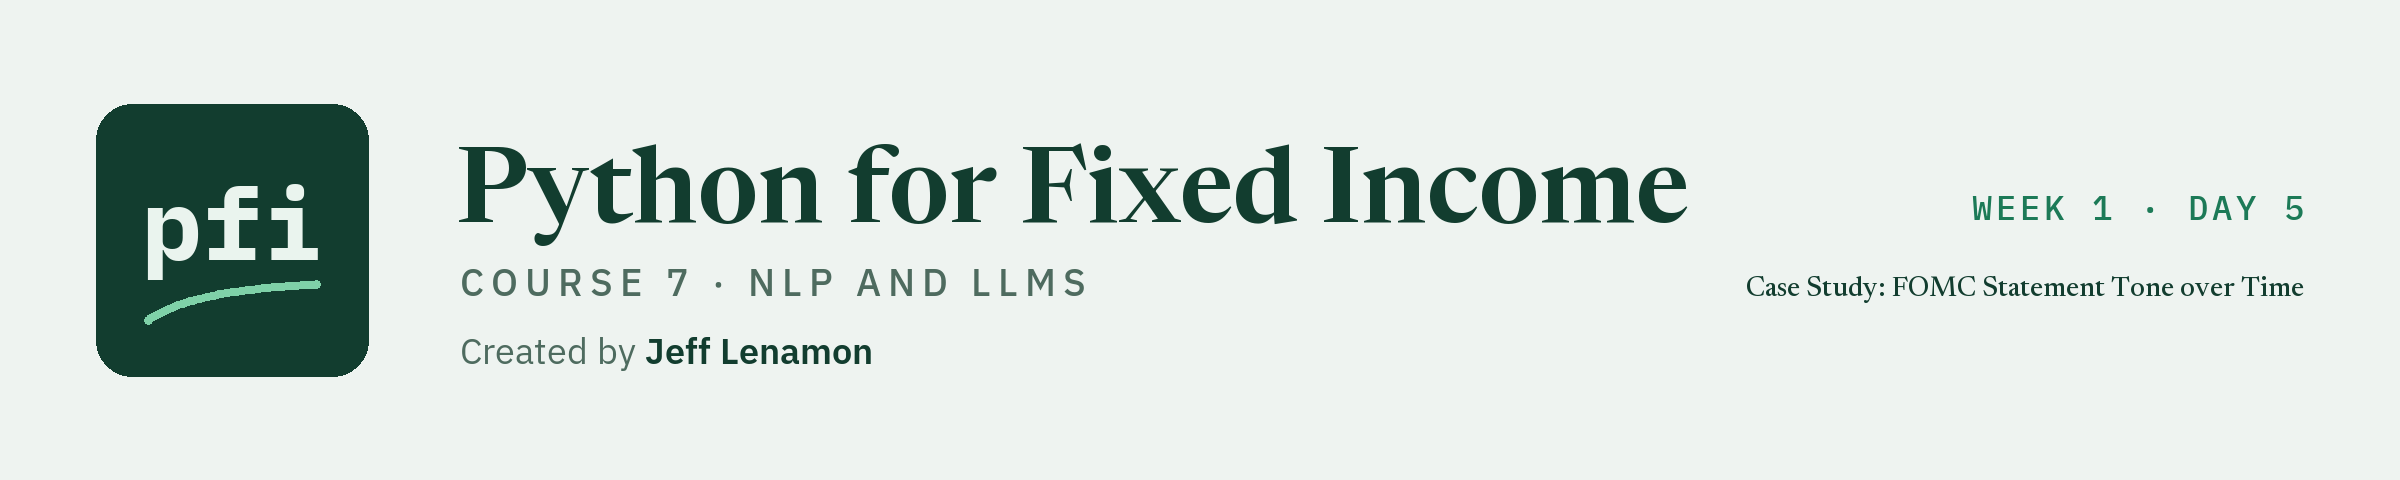

# Case Study: FOMC Statement Tone over Time

Week 1, Day 5. Week 1 ends with a case study: the wording of every FOMC statement from 2000 to 2026, counted with the course's own word lists and scored by a classifier fitted only on earlier years, with the label's own words taken out first.

**Data:** `course7_fomc_statements.csv`, 226 FOMC post-meeting statements, 2000-02-02 to 2026-09-16: **real**, Board of Governors of the Federal Reserve System, public domain (federalreserve.gov).

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course7_nlp_and_llms/week1/day5/05_case_study_fomc_statement_tone_over_time.ipynb)

Days 1 to 4 built the tools of text as data: strings and patterns, tokens, TF-IDF, a classifier, word vectors. Today puts them to work on one dataset, the 226 FOMC post-meeting statements, in two parts. The hands-on part writes the course's two word lists and the two functions that read a statement: `dictionary_score`, a count from a word list, and `policy_action`, the action a statement states. The case study then asks how the wording of the statements moved over 27 years, with two numbers per statement, and says plainly what each one counts and where each one fails.

**The rules for real documents, as on every day of this course.**

* **The documents are real.** The FOMC statements are the Board of Governors' own text, public domain, quoted exactly as published, with a source line under every excerpt.
* **Described, never read for policy.** A score is a count from a stated word list for a statement of a stated date. The classifier's output is the score the model assigns, in this file, that a statement announced a raise. No sentence says what the Committee meant, will do, or should do, no score is lined up against later market moves, and no statement is ever called hawkish or dovish.

**Rows.** Every score from a fitted model in this notebook is walk-forward: a statement of a year is scored by a model fitted only on statements of earlier years; the first scored year is 2005.

Today you will:

1. Write the course's two word lists, print them in full, and score a sentence by hand with `dictionary_score`.
2. Read the action every statement states with `policy_action`, count it by year, and check it against the rate each statement states.
3. Work through a case study: the context, the data, the label-in-the-text leak shown first and then removed with `drop_sentences`, a dictionary score and a classifier scored walk-forward, the two side by side, a workbook, and what the model shows, and where it fails.

Q. Set up today's work folder: the thread settings, the quiet-loading settings, the modules, the seed, and the statements file.

In [1]:
# today's setup: thread settings, quiet model loading, the modules, the seed, the course data, a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These lines must run before numpy, pandas, scikit-learn, or PyTorch is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

# the model libraries print download bars and notices; these lines must run before they are imported
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

import importlib
import importlib.metadata
import importlib.util
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("torch", "torch"), ("transformers", "transformers"), ("sentence_transformers", "sentence-transformers"), ("openai", "openai"), ("pydantic", "pydantic"), ("bs4", "beautifulsoup4"), ("pypdf", "pypdf"), ("pypdfium2", "pypdfium2"), ("dotenv", "python-dotenv"), ("pytest", "pytest")]:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.")

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course7_nlp_and_llms/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "torch": "2.14.1", "transformers": "5.19.0", "sentence-transformers": "6.1.0", "openai": "3.26.0", "pydantic": "2.13.5", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name].split("+")[0] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "course7_fomc_statements.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course7_05_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["course7_fomc_statements.csv"]
for name in DATA_FILES:
    (work / name).parent.mkdir(parents=True, exist_ok=True)
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, torch 2.14.1, transformers 5.19.0, sentence-transformers 6.1.0, openai 3.26.0, pydantic 2.13.5, pytest 9.1.1
Work folder: pfi_course7_05_2m0xwads, in your temp folder
Data files from the data folder of the course repo: course7_fomc_statements.csv
SEED = 42


Q. Write the earlier courses' modules today needs, unchanged: `mlkit.py`, `ensemblekit.py`.

* The setup cell is day 1's, line for line (day 1 explains every line). Today runs no model library, so there is no PyTorch line.
* The next cells write Course 4's `mlkit.py` and, on this one day of week 1, Course 5's `ensemblekit.py`, both unchanged: section 5.6 puts a bootstrap interval on a macro F1 with `ensemblekit.bootstrap_interval`. Then `textkit.py` and its tests as they stand at the end of day 4.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


In [3]:
%%writefile ensemblekit.py
"""ensemblekit: the pieces of ensembles, tuning, and rare-event modelling that the libraries leave to the analyst,
written down and tested.

Written day by day in Python for Fixed Income, Course 5: Advanced Machine Learning. It imports mlkit (Course 4's
module) and never changes it.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- The positive class is 1 (default, bankrupt). A row is flagged when its model output is at least the threshold.
- Course 5 never scores a row that Course 4 used as a test row. The course4_*_rows functions rebuild Course 4's
  splits exactly and return only the rows Course 5 may use; the closed rows are never returned.
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart.
- Every library call that can use more than one thread is given n_jobs=1, so every run gives the same digits.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from sklearn.model_selection import train_test_split  # Course 4's split, rebuilt

import mlkit  # Course 4's module: thresholds, metrics, splitters, and the no-leak check

# the card file: its outcome column and the 19 model columns (the four person columns are never features)
CARD_TARGET = "default payment next month"
CARD_FEATURES = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
    [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]


def course4_card_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's 60/20/20 split of the card file, rebuilt, without its test rows.

    Input: frame, the 30,000 accounts of credit_card_default.csv as read by pd.read_csv.
    Output: X_train (18,000 rows), X_valid (6,000 rows), y_train, y_valid, with the 19 model columns in
    CARD_FEATURES and the file's row labels. Course 4's 6,000 test rows are never returned.
    Convention: the same two calls as Course 4: train_test_split(test_size=0.2, stratify=y, random_state=42), then
    the remaining 80 percent split with test_size=0.25, stratified, same seed. The validation rows were used in
    Course 4 to choose a threshold and a pruning level, never to fit.
    Raises ValueError if a column is missing or the frame does not have 30,000 rows.
    """
    # check the frame is the whole card file
    missing = [name for name in CARD_FEATURES + [CARD_TARGET] if name not in frame.columns]
    if missing:
        raise ValueError(f"frame lacks the columns {missing}")
    if len(frame) != 30_000:
        raise ValueError(f"frame must hold the 30,000 card accounts, not {len(frame)}")
    X, y = frame[CARD_FEATURES], frame[CARD_TARGET]
    # Course 4's first cut puts 20 percent aside as test rows: they are dropped here, never returned
    X_rest, _, y_rest, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    # Course 4's second cut: a quarter of the rest (20 percent of the file) as validation rows
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=42)
    mlkit.assert_disjoint(X_train.index, X_valid.index)
    return X_train, X_valid, y_train, y_valid


def bootstrap_positions(n_rows: int, seed: int = 42) -> np.ndarray:
    """Draw n_rows row positions with replacement: one bootstrap sample.

    Input: n_rows, how many rows the data has (at least 1); seed, the random seed.
    Output: an array of n_rows positions from 0 to n_rows - 1, in the order drawn. A position can appear more than
    once, and some positions do not appear at all (about 36.8 percent of them for large n_rows).
    Convention: np.random.default_rng(seed).integers(0, n_rows, n_rows), so the same seed gives the same sample.
    Excel: =RANDBETWEEN(1,n) draws one position but takes no seed and changes at every recalculation.
    Raises ValueError if n_rows is below 1.
    """
    if n_rows < 1:
        raise ValueError(f"n_rows must be at least 1, not {n_rows}")
    # one generator per call, seeded, so the draw does not depend on anything drawn before
    rng = np.random.default_rng(seed)
    return rng.integers(0, n_rows, n_rows)


def out_of_bag(n_rows: int, drawn: np.ndarray) -> np.ndarray:
    """The positions a bootstrap sample never drew: its out-of-bag rows.

    Inputs: n_rows, how many rows the data has; drawn, the positions of a bootstrap sample.
    Output: the sorted positions from 0 to n_rows - 1 that are not in drawn.
    Convention: a model fitted on the drawn rows has never seen these rows, so they can score it.
    Raises ValueError if drawn is empty or holds a position outside 0 to n_rows - 1.
    """
    positions = np.asarray(drawn)
    if positions.size == 0:
        raise ValueError("drawn is empty")
    if positions.min() < 0 or positions.max() > n_rows - 1:
        raise ValueError(f"drawn holds a position outside 0 to {n_rows - 1}")
    # every position, minus the ones drawn at least once
    return np.setdiff1d(np.arange(n_rows), positions)


from sklearn.metrics import roc_auc_score  # ranking quality from probabilities


def bagged_proba(bagging, X: pd.DataFrame) -> np.ndarray:
    """Bagging by hand: the average of each fitted tree's class-1 probability, each on its own columns.

    Inputs: bagging, a fitted BaggingClassifier; X, the rows to score, with the columns it was fitted on.
    Output: one number per row, the mean over bagging.estimators_ of each tree's class-1 probability on the
    columns listed in bagging.estimators_features_. It equals bagging.predict_proba(X)[:, 1] within 1e-12.
    Convention: a tree whose bootstrap sample held only one class gives 0 for class 1 when that class is 0.
    Excel: with each tree's column of outputs pasted side by side, =AVERAGE(B2:K2) filled down.
    Raises ValueError if bagging is not fitted.
    """
    if not hasattr(bagging, "estimators_"):
        raise ValueError("bagging is not fitted: call fit first")
    # the trees were fitted on plain arrays of the chosen columns, so score them the same way
    values = np.asarray(X, dtype=float)
    total = np.zeros(len(values))
    for tree, columns in zip(bagging.estimators_, bagging.estimators_features_):
        proba = tree.predict_proba(values[:, columns])
        # the tree's classes are positions in bagging.classes_; class 1 is position 1
        position = np.flatnonzero(tree.classes_ == 1)
        total += proba[:, position[0]] if position.size else 0.0
    return total / len(bagging.estimators_)


def oob_auc(model, y_train) -> float:
    """ROC AUC of the out-of-bag probabilities of a bagged model or a random forest.

    Inputs: model, fitted with oob_score=True on the training rows; y_train, those rows' outcomes, in order.
    Output: roc_auc_score(y_train, model.oob_decision_function_[:, 1]): each row scored only by the trees that
    did not draw it.
    Convention: model.oob_score_ is the accuracy of the out-of-bag votes for a classifier, not ROC AUC; this
    function gives the ranking number the course compares models by.
    Raises ValueError if the model was fitted without oob_score=True, or if a row has no out-of-bag vote (too few
    trees, so some row was drawn by every tree).
    """
    if not hasattr(model, "oob_decision_function_"):
        raise ValueError("the model has no out-of-bag outputs: fit it with oob_score=True")
    proba = model.oob_decision_function_[:, 1]
    if np.isnan(proba).any():
        raise ValueError(f"{int(np.isnan(proba).sum())} rows have no out-of-bag vote: use more trees")
    return float(roc_auc_score(y_train, proba))


def tree_correlation(forest, X: pd.DataFrame) -> float:
    """How much the trees of an ensemble agree: the mean pairwise correlation of their class-1 outputs.

    Inputs: forest, a fitted random forest, extra-trees, or bagging model (anything with estimators_, and
    estimators_features_ for bagging); X, the rows to score (validation rows).
    Output: the mean of the upper triangle of np.corrcoef over the trees' class-1 probabilities on X: 1 means
    every tree gives the same ranking, 0 means no linear agreement.
    Convention: averaging trees removes less noise the more they agree; a random forest tries a random subset of
    columns at each split to lower this number.
    Excel: =CORREL(B2:B6001,C2:C6001) for one pair of pasted tree columns.
    Raises ValueError if the ensemble has fewer than two trees.
    """
    trees = list(forest.estimators_)
    if len(trees) < 2:
        raise ValueError(f"need at least two trees, the ensemble has {len(trees)}")
    # each tree was fitted on a plain array; bagging may give each tree its own columns
    values = np.asarray(X, dtype=float)
    columns = getattr(forest, "estimators_features_", [slice(None)] * len(trees))
    outputs = np.array([tree.predict_proba(values[:, cols])[:, -1] for tree, cols in zip(trees, columns)])
    # the correlation of every pair of trees, then the mean above the diagonal
    matrix = np.corrcoef(outputs)
    return float(matrix[np.triu_indices(len(trees), k=1)].mean())


from sklearn.inspection import permutation_importance  # the drop in a score when one column is shuffled


def importance_table(model, X_valid: pd.DataFrame, y_valid, scoring: str = "roc_auc", n_repeats: int = 5,
                     seed: int = 42) -> pd.DataFrame:
    """Two importance measures side by side: impurity importance and permutation importance.

    Inputs: model, a fitted tree ensemble with feature_importances_, fitted on a DataFrame; X_valid, y_valid,
    rows the model was NOT fitted on (validation rows); scoring, the score whose drop is measured; n_repeats, how
    many shuffles per column; seed, the random seed of the shuffles.
    Output: a DataFrame indexed by feature with columns impurity (model.feature_importances_, from the training
    rows, sums to 1), permutation (the mean drop in the score over n_repeats shuffles of that column),
    permutation_sd (their standard deviation), impurity_rank and permutation_rank (1 = largest), sorted by
    permutation, largest first.
    Convention: impurity importance is learned on the training rows and rewards columns the trees could split on
    to fit noise; permutation importance on unseen rows measures how much the score leans on a column there.
    Neither measure is a cause. permutation_importance runs with n_jobs=1.
    Raises ValueError if the model has no feature_importances_ (an unfitted model, or a linear model).
    """
    if not hasattr(model, "feature_importances_"):
        raise ValueError("the model has no feature_importances_: fit a tree ensemble first")
    # shuffle each column n_repeats times on the rows given and record the drop in the score
    result = permutation_importance(model, X_valid, y_valid, scoring=scoring, n_repeats=n_repeats,
                                    random_state=seed, n_jobs=1)
    table = pd.DataFrame({"impurity": model.feature_importances_, "permutation": result.importances_mean,
                          "permutation_sd": result.importances_std}, index=pd.Index(X_valid.columns, name="feature"))
    # rank 1 is the largest value; ties share the better rank
    table["impurity_rank"] = table["impurity"].rank(ascending=False, method="min").astype(int)
    table["permutation_rank"] = table["permutation"].rank(ascending=False, method="min").astype(int)
    return table.sort_values("permutation", ascending=False, kind="stable")


from sklearn.model_selection import cross_val_predict  # out-of-fold outputs, one per row


def course4_bench_rows(bench: pd.DataFrame, ratings: pd.DataFrame) -> pd.DataFrame:
    """Course 4's 615 training bonds of the synthetic benchmark, without its 206 test bonds.

    Inputs: bench, the 821 bonds of benchmark.csv; ratings, ratings.csv (rating and score).
    Output: the 615 training bonds with every column of bench plus score (the rating's number, 1 = AAA),
    log_oas (natural log of oas in bp), years (days from as_of_date to maturity / 365.25), and amount_bn
    (amount_outstanding in billions), with bench's row labels. Course 4's 206 test bonds are never returned.
    Convention: Course 4's split, train_test_split(test_size=0.25, random_state=42) on the joined rows. The bonds
    and their spreads are invented by the course's generator.
    Raises ValueError if bench does not hold 821 bonds.
    """
    if len(bench) != 821:
        raise ValueError(f"bench must hold the 821 benchmark bonds, not {len(bench)}")
    # the rating's number, joined row for row (each rating appears once in ratings)
    frame = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    frame["log_oas"] = np.log(frame["oas"])
    dates = pd.to_datetime(frame["maturity"]) - pd.to_datetime(frame["as_of_date"])
    frame["years"] = dates.dt.days / 365.25
    frame["amount_bn"] = frame["amount_outstanding"] / 1e9
    # Course 4's split: the second part was its test set, dropped here
    train, _ = train_test_split(frame, test_size=0.25, random_state=42)
    return train


def oof_threshold(model, X, y, target_recall: float = 0.70, cv=None) -> tuple[float, np.ndarray]:
    """The course's threshold rule, applied to out-of-fold probabilities on the training rows.

    Inputs: model, an unfitted (or fitted) classifier with predict_proba; X, y, the training rows; target_recall,
    the share of defaults to catch; cv, a splitter (default mlkit.cv_folds(), stratified 5-fold, seed 42).
    Output: (threshold, proba): proba holds each training row's class-1 probability from the fold model that did
    not see it (cross_val_predict, n_jobs=1); threshold is mlkit.threshold_for_recall(y, proba, target_recall),
    the highest threshold whose out-of-fold recall is at least target_recall.
    Convention: the threshold is chosen on training rows only, so validation and test rows stay for reporting.
    cross_val_predict fits clones, so the caller's model is left as it was.
    Raises ValueError from mlkit.threshold_for_recall on a bad target or no row of class 1.
    """
    folds = cv if cv is not None else mlkit.cv_folds()
    proba = cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
    return mlkit.threshold_for_recall(y, proba, target_recall), proba


def samme_alpha(weighted_error: float, learning_rate: float = 1.0) -> float:
    """The weight AdaBoost gives one stump's vote, for two classes.

    Inputs: weighted_error, the stump's error with each row counted by its weight (above 0, below 0.5);
    learning_rate, the shrinkage AdaBoostClassifier applies (default 1.0).
    Output: learning_rate * ln((1 - e) / e), in natural logs. A stump right on 80 percent of the weight gets
    ln(4) = 1.3863; one barely better than a coin gets almost 0.
    Convention: the SAMME weight with two classes (its extra term ln(classes - 1) is ln 1 = 0); it equals
    AdaBoostClassifier's estimator_weights_.
    Excel: =LN((1-e)/e).
    Raises ValueError unless 0 < weighted_error < 0.5.
    """
    if not 0 < weighted_error < 0.5:
        raise ValueError(f"weighted_error must be above 0 and below 0.5, not {weighted_error}")
    return float(learning_rate * np.log((1 - weighted_error) / weighted_error))


def reweight(weights: np.ndarray, missed: np.ndarray, alpha: float) -> np.ndarray:
    """AdaBoost's new row weights after one round: the rows the stump missed count for more.

    Inputs: weights, the current row weights (non-negative); missed, 1 where the stump was wrong and 0 where it
    was right, the same length; alpha, the stump's weight (samme_alpha).
    Output: weights * exp(alpha * missed), divided by their sum so the new weights sum to 1.
    Excel: =w*EXP(alpha*miss) filled down, then each divided by the column's SUM.
    Raises ValueError if the lengths differ, the input is empty, or a weight is negative.
    """
    w = np.asarray(weights, dtype=float)
    m = np.asarray(missed, dtype=float)
    if w.size == 0 or w.shape != m.shape:
        raise ValueError(f"weights and missed must be non-empty and the same length, not {w.size} and {m.size}")
    if (w < 0).any():
        raise ValueError("weights must not be negative")
    # a missed row is multiplied by e^alpha, a correct row by 1
    new = w * np.exp(alpha * m)
    return new / new.sum()


from sklearn.tree import DecisionTreeRegressor  # one round's tree, fitted to the residuals


def boost_by_hand(X, y, n_rounds: int, learning_rate: float, max_depth: int, seed: int = 42) -> np.ndarray:
    """Gradient boosting for a squared error, by hand: start from the mean, then fit trees to the residuals.

    Inputs: X, the feature rows; y, the target (for example log_oas); n_rounds, how many trees; learning_rate,
    the fraction of each tree's output added; max_depth, each tree's depth; seed, each tree's random_state.
    Output: the fitted values on X after n_rounds: F0 = mean(y), then for each round
    F = F + learning_rate * tree.predict(X), with the tree fitted to the residuals y - F.
    Convention: equals GradientBoostingRegressor(n_estimators=n_rounds, learning_rate=..., max_depth=...,
    random_state=seed).predict(X) on the rows it was fitted on, within 1e-12. No criterion= is passed (scikit-learn
    1.9 deprecates "friedman_mse" for a regression tree).
    Excel: one round is =y-F, the two leaf means by AVERAGEIFS on either side of the stump's threshold, and
    =F+lr*IF(x<=t,left,right).
    Raises ValueError if n_rounds is below 1 or learning_rate is not positive.
    """
    if n_rounds < 1 or learning_rate <= 0:
        raise ValueError(f"n_rounds must be at least 1 and learning_rate positive, not {n_rounds}, {learning_rate}")
    target = np.asarray(y, dtype=float)
    # round 0: every row's fitted value is the mean
    fitted = np.full(target.size, target.mean())
    for _ in range(n_rounds):
        # fit a small tree to what is still unexplained, then add a fraction of it
        tree = DecisionTreeRegressor(max_depth=max_depth, random_state=seed).fit(X, target - fitted)
        fitted = fitted + learning_rate * tree.predict(X)
    return fitted


def mae_bp(log_true, log_fitted) -> float:
    """Mean absolute error in bp of a model fitted on log spreads.

    Inputs: log_true and log_fitted, natural logs of spreads in bp, the same length.
    Output: mean(|exp(log_true) - exp(log_fitted)|), in bp.
    Convention: the course's benchmark metric; exp of a fitted log is a median-type value, not a mean.
    Excel: =AVERAGE(ABS(EXP(a)-EXP(b))).
    Raises ValueError if the inputs are empty or of different lengths.
    """
    true, fitted = np.asarray(log_true, dtype=float), np.asarray(log_fitted, dtype=float)
    if true.size == 0 or true.shape != fitted.shape:
        raise ValueError(f"inputs must be non-empty and the same length, not {true.size} and {fitted.size}")
    return float(np.mean(np.abs(np.exp(true) - np.exp(fitted))))


def early_stopping_rows(X_train, y_train, fraction: float = 0.2, seed: int = 42) -> tuple:
    """Carve stopping rows out of the training rows, for early stopping, so no report row chooses the trees.

    Inputs: X_train, y_train, the training rows; fraction, the share set aside to stop on (above 0, below 0.5);
    seed, the split's seed.
    Output: X_fit, X_stop, y_fit, y_stop: a stratified split of the training rows only. Fit on X_fit and pass
    (X_stop, y_stop) as eval_set; validation and test rows are never an eval_set.
    Convention: train_test_split(test_size=fraction, stratify=y_train, random_state=seed), checked with
    mlkit.assert_disjoint.
    Raises ValueError unless 0 < fraction < 0.5.
    """
    if not 0 < fraction < 0.5:
        raise ValueError(f"fraction must be above 0 and below 0.5, not {fraction}")
    X_fit, X_stop, y_fit, y_stop = train_test_split(X_train, y_train, test_size=fraction, stratify=y_train,
                                                    random_state=seed)
    mlkit.assert_disjoint(X_fit.index, X_stop.index)
    return X_fit, X_stop, y_fit, y_stop


def scale_pos_weight(y) -> float:
    """XGBoost's weight for the rare class: negatives divided by positives.

    Input: y, the outcomes of the training rows (0 or 1).
    Output: (number of 0s) / (number of 1s). On Course 4's card training rows about 3.5.
    Convention: passed as XGBClassifier(scale_pos_weight=...); the model's output is then a score whose average
    is above the outcome rate, not a probability.
    Raises ValueError if y is empty or has no positive.
    """
    outcomes = np.asarray(y)
    positives = int((outcomes == 1).sum())
    if positives == 0:
        raise ValueError("y has no row of class 1")
    return float((outcomes == 0).sum() / positives)


def stack_inputs(models: dict, X, y, cv=None) -> pd.DataFrame:
    """The columns a stack's final model is fitted on: each base model's out-of-fold class-1 probability.

    Inputs: models, {name: classifier with predict_proba}; X, y, the training rows; cv, a splitter (default
    mlkit.cv_folds()).
    Output: a DataFrame with X's row labels and one column per model, in the order of models: each row's
    probability from the fold model that did not see it (cross_val_predict, n_jobs=1).
    Convention: what StackingClassifier(stack_method="predict_proba", cv=cv) feeds its final estimator for two
    classes. A final model fitted on in-sample outputs would learn to trust the base models too much.
    Raises ValueError if models is empty.
    """
    if not models:
        raise ValueError("models is empty")
    folds = cv if cv is not None else mlkit.cv_folds()
    columns = {name: cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
               for name, model in models.items()}
    return pd.DataFrame(columns, index=X.index)


def bootstrap_interval(y_true, proba, metric, n_boot: int = 1000, level: float = 0.95,
                       seed: int = 42) -> tuple[float, float]:
    """A percentile interval for a metric, from resampling the scored rows.

    Inputs: y_true, the outcomes of the scored rows (0 or 1); proba, the model's outputs on them; metric, a
    function metric(y_true, proba) such as roc_auc_score; n_boot, how many resamples; level, the interval's
    coverage (0.95 for a 95 percent interval); seed, the resampling seed.
    Output: (lower, upper), numpy.percentile (linear) of the n_boot values at (1 - level) / 2 and (1 + level) / 2.
    Convention: each resample draws len(y_true) rows with replacement by np.random.default_rng(seed); a resample
    holding one class only is drawn again. The interval describes the noise from which rows happened to be
    scored, not the noise from refitting the model.
    Excel: =PERCENTILE.INC(range,0.025) and =PERCENTILE.INC(range,0.975) on the pasted resampled values.
    Raises ValueError on inputs of different lengths, fewer than both classes, n_boot below 1, or level outside
    (0, 1).
    """
    actual, scores = np.asarray(y_true), np.asarray(proba, dtype=float)
    if actual.size == 0 or actual.shape != scores.shape:
        raise ValueError(f"y_true and proba must be non-empty and the same length, not {actual.size} and {scores.size}")
    if len(np.unique(actual)) < 2:
        raise ValueError("y_true must hold both classes")
    if n_boot < 1 or not 0 < level < 1:
        raise ValueError(f"n_boot must be at least 1 and level between 0 and 1, not {n_boot}, {level}")
    rng = np.random.default_rng(seed)
    values = []
    while len(values) < n_boot:
        rows = rng.integers(0, actual.size, actual.size)
        # a resample with one class has no ROC AUC; draw again
        if len(np.unique(actual[rows])) < 2:
            continue
        values.append(metric(actual[rows], scores[rows]))
    lower, upper = np.percentile(values, [100 * (1 - level) / 2, 100 * (1 + level) / 2])
    return float(lower), float(upper)


from sklearn.model_selection import cross_val_score  # one score per fold


def course4_polish_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    """Course 4's 4,680 training rows of the Polish bankruptcy file, without its 1,170 test rows.

    Input: frame, the 5,910 rows of polish_bankruptcy_5year.csv read with float_precision="round_trip".
    Output: X_train (Attr1 to Attr64, missing values kept) and y_train (class), 4,680 rows, 326 of them bankrupt,
    with the file's row labels. Course 4's 1,170 test rows are never returned.
    Convention: Course 4's capstone steps: exact duplicate rows dropped (5,910 to 5,850), then
    train_test_split(test_size=0.2, stratify=y, random_state=42).
    Raises ValueError if the frame does not hold 5,910 rows with a class column.
    """
    if len(frame) != 5_910 or "class" not in frame.columns:
        raise ValueError(f"frame must be the 5,910 rows of the Polish file with a class column, not {len(frame)} rows")
    unique = frame.drop_duplicates()
    X, y = unique.drop(columns="class"), unique["class"]
    # Course 4's split: the second part was its test set, dropped here
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    return X_train, y_train


def nested_score(search, X, y, outer=None, scoring: str = "average_precision") -> pd.Series:
    """An honest score for a tuned model: the whole search is repeated inside each outer fold.

    Inputs: search, an unfitted RandomizedSearchCV or GridSearchCV that carries its own inner cv; X, y, the
    training rows; outer, the outer splitter (default mlkit.cv_folds()); scoring, the metric.
    Output: one score per outer fold, indexed fold_1, fold_2, ...: each fold's search tunes on the other folds
    only and is scored on its own held-out rows (cross_val_score, n_jobs=1).
    Convention: a search's best_score_ is the best of many noisy numbers and is not an honest score of the model it
    chose; the mean of this Series is.
    Raises ValueError if the search has no inner cv.
    """
    if getattr(search, "cv", None) is None:
        raise ValueError("give the search its own inner cv, for example StratifiedKFold(3, shuffle=True, random_state=42)")
    folds = outer if outer is not None else mlkit.cv_folds()
    scores = cross_val_score(search, X, y, cv=folds, scoring=scoring, n_jobs=1)
    return pd.Series(scores, index=[f"fold_{i}" for i in range(1, len(scores) + 1)], name=scoring)


def search_table(search, top: int = 5) -> pd.DataFrame:
    """A fitted search's results as a short table, best first.

    Inputs: search, a fitted RandomizedSearchCV or GridSearchCV; top, how many candidates to keep.
    Output: columns rank, mean, sd (the mean and standard deviation of the fold scores, ddof=0, as cv_results_),
    then one column per searched parameter (the param_ prefix dropped), sorted by rank.
    Excel: =AVERAGE and =STDEV.P of a candidate's five fold scores give its mean and sd (STDEV.S does not).
    Raises ValueError if the search is not fitted.
    """
    if not hasattr(search, "cv_results_"):
        raise ValueError("the search is not fitted: call fit first")
    results = pd.DataFrame(search.cv_results_)
    params = [name for name in results.columns if name.startswith("param_")]
    table = results[["rank_test_score", "mean_test_score", "std_test_score"] + params]
    table.columns = ["rank", "mean", "sd"] + [name[len("param_"):] for name in params]
    return table.sort_values("rank", kind="stable").head(top).reset_index(drop=True)


from sklearn.base import BaseEstimator, TransformerMixin  # what makes a class a scikit-learn transformer
from sklearn.utils.validation import check_is_fitted  # stops a transformer used before fit


def safe_ratio(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    """A ratio of two columns that is never infinite: missing where the denominator is 0 or either side is missing.

    Inputs: numerator, denominator, two Series with the same row labels.
    Output: numerator / denominator as floats, with NaN where the denominator is 0 or either value is missing.
    Convention: a model that handles missing values (or an imputer inside a pipeline) then deals with those rows;
    an infinity would break most estimators.
    Excel: =IF(OR(B2=0,B2="",A2=""),NA(),A2/B2), where =A2/B2 alone gives #DIV/0!.
    Raises ValueError if the two Series do not have the same row labels.
    """
    if not numerator.index.equals(denominator.index):
        raise ValueError("numerator and denominator must have the same row labels")
    defined = denominator.ne(0) & numerator.notna() & denominator.notna()
    # divide only where the ratio is defined; every other row stays NaN
    return numerator.astype(float).div(denominator.astype(float).where(defined)).where(defined)


class ClipToTraining(TransformerMixin, BaseEstimator):
    """Clip each column to bounds learned from the rows it is fitted on (by default the 1st and 99th percentiles).

    Inside a pipeline, fit sees only each fold's training rows, so the bounds never come from held-out rows.
    Parameters: lower, upper, the quantiles (0 <= lower < upper <= 1).
    Fitted attributes: lower_, upper_, one bound per column (numpy.nanquantile, linear, missing values ignored);
    n_features_in_; feature_names_in_ when fitted on a DataFrame.
    transform returns a float array; a missing value stays missing.
    Excel: =PERCENTILE.INC(training_range,0.01) and 0.99 give the bounds; =MIN(MAX(x,low),high) clips.
    """

    def __init__(self, lower: float = 0.01, upper: float = 0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        if not 0 <= self.lower < self.upper <= 1:
            raise ValueError(f"need 0 <= lower < upper <= 1, not {self.lower}, {self.upper}")
        values = np.asarray(X, dtype=float)
        if hasattr(X, "columns"):
            self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.n_features_in_ = values.shape[1]
        # each column's bounds, from these rows only
        self.lower_ = np.nanquantile(values, self.lower, axis=0)
        self.upper_ = np.nanquantile(values, self.upper, axis=0)
        return self

    def transform(self, X):
        check_is_fitted(self, ["lower_", "upper_"])
        values = np.asarray(X, dtype=float)
        if values.shape[1] != self.n_features_in_:
            raise ValueError(f"X has {values.shape[1]} columns, the transformer was fitted on {self.n_features_in_}")
        return np.clip(values, self.lower_, self.upper_)

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, ["lower_", "upper_"])
        if input_features is not None:
            return np.asarray(input_features, dtype=object)
        if hasattr(self, "feature_names_in_"):
            return self.feature_names_in_
        return np.asarray([f"x{i}" for i in range(self.n_features_in_)], dtype=object)


def class_counts_after(sampler, X, y) -> pd.Series:
    """How many rows of each class a resampler leaves: for showing what a sampler does.

    Inputs: sampler, an imbalanced-learn sampler such as SMOTE(random_state=42); X, y, rows with no missing value.
    Output: the count of each class after sampler.fit_resample(X, y), indexed by class.
    Convention: a demonstration only. Rows a model is scored on are never resampled; resampling belongs inside an
    imblearn pipeline, where cross-validation resamples each fold's training rows only.
    """
    _, y_resampled = sampler.fit_resample(X, y)
    return pd.Series(y_resampled).value_counts().sort_index()


def prior_correction(score, fitted_rate: float, true_rate: float) -> np.ndarray:
    """Move a score from a model fitted at one outcome rate back to the rate of the real rows.

    Inputs: score, the model's outputs (between 0 and 1); fitted_rate, the outcome rate of the rows the model was
    fitted on (0.5 after SMOTE to balance); true_rate, the outcome rate of the real training rows.
    Output: each score's odds multiplied by k = (true_rate / (1 - true_rate)) / (fitted_rate / (1 - fitted_rate)),
    turned back into a number between 0 and 1: s * k / (s * k + 1 - s).
    Convention: a closed form that assumes resampling changed only the class shares; it leaves the ranking of rows
    unchanged. Equal rates give the score back.
    Excel: k in one cell, =(t/(1-t))/(f/(1-f)), then =p*k/(p*k+1-p) filled down.
    Raises ValueError if a rate is not strictly between 0 and 1 or a score is outside [0, 1].
    """
    for name, rate in (("fitted_rate", fitted_rate), ("true_rate", true_rate)):
        if not 0 < rate < 1:
            raise ValueError(f"{name} must be strictly between 0 and 1, not {rate}")
    s = np.asarray(score, dtype=float)
    if s.size == 0 or (s < 0).any() or (s > 1).any():
        raise ValueError("score must be non-empty and between 0 and 1")
    # the factor that moves odds from the fitted rate to the true rate
    k = (true_rate / (1 - true_rate)) / (fitted_rate / (1 - fitted_rate))
    return s * k / (s * k + 1 - s)


import re  # whole-word search

# words that turn a description of a model into a claim about causes; a reminder, not a proof
EXPLANATION_WORDS = ["cause", "causes", "caused", "driver", "drivers", "drives", "reason", "reasons", "because"]


def shap_table(shap_values, top: int | None = None) -> pd.DataFrame:
    """Mean absolute SHAP value per feature, largest first.

    Inputs: shap_values, a shap.Explanation for one output (rows by features), for example
    shap.TreeExplainer(model)(X); top, how many features to keep (all if None).
    Output: a DataFrame indexed by feature with columns mean_abs_shap (the average size of the feature's
    contribution to the model's log-odds, in log-odds) and rank (1 = largest).
    Convention: a SHAP value describes how the model's output for a row splits across features; it is not the
    effect of changing a feature and not a cause.
    Excel: =AVERAGE(ABS(column)) on a pasted column of SHAP values.
    Raises ValueError if the values are not one row per observation and one column per feature.
    """
    values = np.asarray(shap_values.values, dtype=float)
    if values.ndim != 2 or values.shape[1] != len(shap_values.feature_names):
        raise ValueError(f"expected rows by features, got shape {values.shape}")
    table = pd.DataFrame({"mean_abs_shap": np.abs(values).mean(axis=0)},
                         index=pd.Index(shap_values.feature_names, name="feature"))
    table = table.sort_values("mean_abs_shap", ascending=False, kind="stable")
    table["rank"] = np.arange(1, len(table) + 1)
    return table if top is None else table.head(top)


def assert_additive(shap_values, raw_score, tol: float = 1e-9) -> None:
    """Stop unless each row's SHAP values add up to the model's raw output (log-odds).

    Inputs: shap_values, a shap.Explanation for one output; raw_score, the model's log-odds for the same rows
    (LightGBM: predict(X, raw_score=True); XGBoost: predict(X, output_margin=True)); tol, the largest gap allowed
    (1e-9 for LightGBM; 1e-5 for XGBoost, which computes in float32).
    Output: None when base value + the row's SHAP values equals raw_score in every row within tol.
    Convention: the contributions add up in log-odds, not in probability; mlkit.logistic_probability turns the sum
    into the model's probability.
    Raises AssertionError naming the largest gap and its row position, and ValueError on lengths that differ.
    """
    values = np.asarray(shap_values.values, dtype=float)
    raw = np.asarray(raw_score, dtype=float)
    if values.ndim != 2 or values.shape[0] != raw.size:
        raise ValueError(f"shap_values has {values.shape[0]} rows and raw_score {raw.size}")
    # base value plus the row's contributions, against the model's own log-odds
    gaps = np.abs(np.asarray(shap_values.base_values, dtype=float) + values.sum(axis=1) - raw)
    worst = int(np.argmax(gaps))
    if gaps[worst] > tol:
        raise AssertionError(f"SHAP values do not add up to raw_score: largest gap {gaps[worst]:.3g} at row "
                             f"position {worst} (tolerance {tol:g}); raw_score must be log-odds, not a probability")


def assert_described(text: str) -> None:
    """Stop if a written description uses a forecast word or a cause word.

    Input: text, a description of what a model shows.
    Output: None if the text passes mlkit.assert_descriptive and holds no word of EXPLANATION_WORDS as a whole word,
    in any case.
    Convention: the lists are a reminder, not a proof. "because" is on the list so the writer looks again at every
    causal sentence; a description that needs it rewrites the sentence.
    Raises ValueError naming the words found.
    """
    mlkit.assert_descriptive(text)
    found = [word for word in EXPLANATION_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses cause or explanation words: {found}")

Writing ensemblekit.py


Q. Write `textkit.py` and `test_textkit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [4]:
%%writefile textkit.py
"""textkit: text as data for fixed income, from a regular expression to a checked LLM extraction.

Written day by day in Python for Fixed Income, Course 7: NLP and LLMs.

Conventions, the same in every function:
- Text is normalized by normalize_text before it is counted, searched, or compared: Unicode NFC, a fixed map of
  look-alike characters (no-break space, non-breaking hyphen, curly quotes, dashes), one space for every run of
  white space, and one newline between paragraphs. Source files keep the text exactly as published.
- A token is a run of lower-case letters and digits, joined by single hyphens, apostrophes, or full stops
  (TOKEN_PATTERN): "mortgage-backed" and "4.750" are one token each, "1/4" is two. No stemming.
- Section numbers and 8-K item codes are text ("4.12", "2.04"), so "4.10" never becomes 4.1.
- Money is in US dollars as whole numbers of dollars (855_000_000); percentages are as the source writes them
  (15.0 means 15.0 percent); ratios are floats with the unit "x" (2.0 means 2.00 to 1.00).
- The seed is 42 wherever a function takes one.
- Every output describes what a document says. Nothing here is a forecast, a rating, or a credit view.
- Empty inputs, or inputs of the wrong shape, raise ValueError with a message that says what was wrong.
"""
import re  # regular expressions
import unicodedata  # Unicode normalization

import pandas as pd  # tables with labels

import mlkit  # Course 4's module, unchanged: the split checks and the description check

# one token: letters and digits, joined by single hyphens, apostrophes, or full stops
TOKEN_PATTERN = r"[a-z0-9]+(?:[-'.][a-z0-9]+)*"
# a section heading at the start of a line: "Section 4.12. Limitation on Indebtedness" or "SECTION 4.12"; the
# title, if any, starts with a capital letter or "[", so a cross-reference that starts a line ("Section 4.12(b)",
# "Section 4.13 or Section 4.19 of the Indenture") is not a heading
SECTION_PATTERN = (r"^[ \t]*(?:SECTION|Section)[ \t]+(?P<number>\d{1,2}\.\d{1,2})(?![\d(])\.?"
                   r"(?:[ \t]+(?P<title>[A-Z\[][^\n]*?))?[ \t]*(?:\.(?=[ \t]|$)|$)")
# look-alike characters and the plain character each becomes (COURSE7_SPEC.md, "Conventions")
CHARACTER_MAP = {
    "\u00a0": " ",  # no-break space
    "\u2010": "-",  # hyphen
    "\u2011": "-",  # non-breaking hyphen
    "\u2013": "-",  # en dash
    "\u2014": "-",  # em dash
    "\u2018": "'",  # left single quote
    "\u2019": "'",  # right single quote
    "\u201c": '"',  # left double quote
    "\u201d": '"',  # right double quote
}


def normalize_text(text: str) -> str:
    """Return text with look-alike characters made plain and white space tidied.

    Input: text, any string.
    Output: the text after three steps: Unicode NFC; each character of CHARACTER_MAP replaced by its plain form;
    every run of white space that holds a line break becomes one newline (a paragraph break), and every other run
    of white space becomes one space; no space or newline at either end.
    Convention: idempotent, so normalize_text(normalize_text(t)) == normalize_text(t). Run it on both sides of any
    comparison of text.
    Raises ValueError if text is not a string.
    """
    if not isinstance(text, str):
        raise ValueError(f"text must be a string, not {type(text).__name__}")
    # one code point per accented letter, then the fixed map
    text = unicodedata.normalize("NFC", text).translate(str.maketrans(CHARACTER_MAP))
    # a run of white space with a line break in it is a paragraph break; any other run is one space
    text = re.sub(r"[^\S\n]*\n\s*", "\n", text)
    text = re.sub(r"[^\S\n]+", " ", text)
    return text.strip()


def tokenize(text: str, lower: bool = True) -> list[str]:
    """Split text into tokens with TOKEN_PATTERN, after normalize_text.

    Inputs: text; lower, True to lower-case first (the course's default; GloVe and TF-IDF are lower case).
    Output: the tokens in the order they appear. With lower=False the pattern runs ignoring case and each token
    keeps its case. A text with no letter or digit gives an empty list.
    Convention: "mortgage-backed", "longer-term", "4.750", and "company's" are one token each; "1/4" is two
    ("1", "4"), because a slash is not a joiner. No stop words are removed and no word is stemmed.
    Raises ValueError if text is not a string.
    """
    text = normalize_text(text)
    if lower:
        return re.findall(TOKEN_PATTERN, text.lower())
    return re.findall(TOKEN_PATTERN, text, flags=re.IGNORECASE)


def find_sections(text: str, pattern: str = SECTION_PATTERN) -> pd.DataFrame:
    """Find the section headings of an indenture and where each section starts and ends.

    Inputs: text, the indenture after normalize_text (one paragraph per line); pattern, a regular expression run
    with re.MULTILINE that has the named groups number and title (title may be empty).
    Output: a DataFrame with one row per section, in the order of the text: number (text, "4.12"), title, start
    (the heading's first character), end (the next kept heading's start, or the end of the text).
    Convention: an indenture lists every section twice, once in the table of contents and once in the body, so for
    each number only the last heading is kept: the body's. A heading must start a line.
    Raises ValueError if no heading is found.
    """
    found = {}
    for match in re.finditer(pattern, text, flags=re.MULTILINE):
        # a later heading with the same number replaces an earlier one: the table of contents comes first
        found[match.group("number")] = (match.start(), (match.group("title") or "").strip())
    if not found:
        raise ValueError("no section heading found; check the pattern against one heading of the text")
    rows = sorted(((start, number, title) for number, (start, title) in found.items()))
    starts = [start for start, _, _ in rows] + [len(text)]
    return pd.DataFrame({"number": [number for _, number, _ in rows], "title": [title for _, _, title in rows],
                         "start": starts[:-1], "end": starts[1:]})


def defined_terms(text: str) -> pd.DataFrame:
    """Find every definition of the form "Term" means ... or "Term" has the meaning ...

    Input: text, for example Section 1.01 of an indenture; curly quotes are made straight by normalize_text first,
    so start values count characters of the normalized text.
    Output: a DataFrame with one row per definition, in the order of the text: term (without its quotes), start
    (the opening quote's position in the normalized text), kind ("means" or "has the meaning").
    Convention: a term starts with a capital letter or a digit. Duplicates are kept, so a term defined twice shows
    twice; count them with value_counts.
    Raises ValueError if text is not a string.
    """
    text = normalize_text(text)
    pattern = r'"(?P<term>[A-Z0-9][^"\n]{0,100}?)"\s+(?P<kind>means|has the meaning)\b'
    rows = [{"term": m.group("term"), "start": m.start(), "kind": m.group("kind")}
            for m in re.finditer(pattern, text)]
    return pd.DataFrame(rows, columns=["term", "start", "kind"])


import numpy as np  # arrays, from day 2


def term_counts(docs: list[str], vocabulary: list[str] | None = None) -> pd.DataFrame:
    """Count each term in each document: the bag of words.

    Inputs: docs, a list of texts; vocabulary, the terms to count, in the order wanted (None counts every token
    found, with the columns sorted alphabetically).
    Output: a DataFrame of whole numbers, one row per document (in input order) and one column per term; a term
    missing from a document counts 0.
    Convention: tokens come from tokenize (lower case, TOKEN_PATTERN), so on plain ASCII text the table equals
    CountVectorizer(token_pattern=TOKEN_PATTERN) on the same vocabulary.
    Raises ValueError if docs is empty.
    """
    if len(docs) == 0:
        raise ValueError("docs is empty")
    tokens = [tokenize(doc) for doc in docs]
    columns = list(vocabulary) if vocabulary is not None else sorted({t for doc in tokens for t in doc})
    position = {term: j for j, term in enumerate(columns)}
    counts = np.zeros((len(docs), len(columns)), dtype=np.int64)
    for i, doc in enumerate(tokens):
        for token in doc:
            if token in position:
                counts[i, position[token]] += 1
    return pd.DataFrame(counts, columns=columns)


def idf(doc_freq, n_docs: int) -> np.ndarray:
    """Inverse document frequency with scikit-learn's smoothing: ln((1 + n) / (1 + df)) + 1.

    Inputs: doc_freq, the number of documents each term appears in (an array of whole numbers); n_docs, the number
    of documents.
    Output: a float64 array, one weight per term. A term in every document gets 1.0, never 0; a rarer term gets
    more.
    Convention: equal to TfidfVectorizer(smooth_idf=True).idf_ (the default). The log is natural.
    Raises ValueError if doc_freq is empty, any df is below 0 or above n_docs, or n_docs is below 1.
    """
    df = np.asarray(doc_freq, dtype=np.float64)
    if df.size == 0 or n_docs < 1:
        raise ValueError("doc_freq must hold at least one term and n_docs must be at least 1")
    if (df < 0).any() or (df > n_docs).any():
        raise ValueError(f"every document frequency must be between 0 and n_docs ({n_docs})")
    return np.log((1.0 + n_docs) / (1.0 + df)) + 1.0


def tfidf_by_hand(counts, sublinear: bool = False) -> np.ndarray:
    """TF-IDF from a table of raw counts, each row scaled to length 1.

    Inputs: counts, documents by terms (an array or a DataFrame from term_counts); sublinear, True to use
    1 + ln(tf) in place of tf for every count above 0 (scikit-learn's sublinear_tf).
    Output: a float64 array of the same shape: term frequency times idf, then each row divided by its Euclidean
    length. A document with no counted term stays a row of zeros.
    Convention: equal to TfidfVectorizer on the same vocabulary within 1e-12 (smooth idf, l2 norm).
    Raises ValueError if counts is not two-dimensional or holds a negative count.
    """
    tf = np.asarray(counts, dtype=np.float64)
    if tf.ndim != 2 or tf.size == 0:
        raise ValueError("counts must be a non-empty table of documents by terms")
    if (tf < 0).any():
        raise ValueError("counts must not be negative")
    weights = idf((tf > 0).sum(axis=0), tf.shape[0])
    if sublinear:
        tf = np.where(tf > 0, 1.0 + np.log(np.where(tf > 0, tf, 1.0)), 0.0)
    matrix = tf * weights
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    # a zero row has length 0: divide by 1 instead, so it stays zero rather than becoming NaN
    return matrix / np.where(norms == 0, 1.0, norms)


def cosine_similarity_matrix(A, B=None) -> np.ndarray:
    """Cosine similarity of every row of A with every row of B (or of A with itself).

    Inputs: A and B, arrays of rows by features (B None means B = A).
    Output: a float64 array, rows of A by rows of B: the dot product of two rows divided by the product of their
    lengths, between -1 and 1. A row of zeros gives 0 with every row, never NaN.
    Convention: equal to sklearn.metrics.pairwise.cosine_similarity within 1e-12. A cosine is a measure of
    direction, not a probability.
    Raises ValueError if A or B is not two-dimensional or their numbers of columns differ.
    """
    A = np.asarray(A, dtype=np.float64)
    B = A if B is None else np.asarray(B, dtype=np.float64)
    if A.ndim != 2 or B.ndim != 2 or A.shape[1] != B.shape[1] or A.size == 0 or B.size == 0:
        raise ValueError("A and B must be non-empty tables with the same number of columns")
    norm_a = np.linalg.norm(A, axis=1, keepdims=True)
    norm_b = np.linalg.norm(B, axis=1, keepdims=True)
    return (A / np.where(norm_a == 0, 1.0, norm_a)) @ (B / np.where(norm_b == 0, 1.0, norm_b)).T


from sklearn.feature_extraction.text import TfidfVectorizer  # TF-IDF, from day 3
from sklearn.linear_model import LogisticRegression  # the classifier, from day 3
from sklearn.metrics import precision_recall_fscore_support  # per-label scores, from day 3
from sklearn.pipeline import Pipeline  # steps fitted together on training rows, from day 3

# the eight Form 8-K items in the course's file, with the titles of the SEC's Form 8-K
ITEM_TITLES = {
    "1.01": "Entry into a Material Definitive Agreement",
    "1.03": "Bankruptcy or Receivership",
    "2.02": "Results of Operations and Financial Condition",
    "2.03": "Creation of a Direct Financial Obligation or an Obligation under an Off-Balance Sheet Arrangement "
            "of a Registrant",
    "2.04": "Triggering Events That Accelerate or Increase a Direct Financial Obligation or an Obligation under "
            "an Off-Balance Sheet Arrangement",
    "2.06": "Material Impairments",
    "3.01": "Notice of Delisting or Failure to Satisfy a Continued Listing Rule or Standard; Transfer of Listing",
    "5.02": "Departure of Directors or Certain Officers; Election of Directors; Appointment of Certain Officers; "
            "Compensatory Arrangements of Certain Officers",
}


def text_classifier(C: float = 1.0, class_weight=None) -> Pipeline:
    """The course's text classifier: TF-IDF, then a logistic regression, in one Pipeline.

    Inputs: C, the inverse of the regularization strength (smaller C, smaller coefficients); class_weight, None or
    "balanced" (weights each class by the inverse of its share of the training rows).
    Output: an unfitted Pipeline with steps "tfidf" (TfidfVectorizer(sublinear_tf=True, min_df=2,
    ngram_range=(1, 2), token_pattern=TOKEN_PATTERN, lowercase=True)) and "logistic" (LogisticRegression(C=C,
    max_iter=2000, random_state=42, class_weight=class_weight), the lbfgs solver, one multinomial model across all
    classes).
    Convention: the vocabulary and idf are learned inside fit, from the training rows only. Its outputs are the
    probabilities the model assigns in this file, or the item it assigns; with class weights, scores.
    """
    tfidf = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2), token_pattern=TOKEN_PATTERN,
                            lowercase=True)
    logistic = LogisticRegression(C=C, max_iter=2000, random_state=42, class_weight=class_weight)
    return Pipeline([("tfidf", tfidf), ("logistic", logistic)])


def date_split(frame: pd.DataFrame, date_column: str, train_end: str, valid_end: str) -> tuple:
    """Split dated rows into training, validation, and test rows by date, never at random.

    Inputs: frame; date_column, the column of dates (text "2024-03-01" or datetimes); train_end and valid_end,
    the last dates of the training and validation rows.
    Output: (train, valid, test), three DataFrames: rows dated on or before train_end; after train_end and on or
    before valid_end; after valid_end. Each keeps the frame's index and columns.
    Convention: a company files similar wording quarter after quarter, so a random split puts a filer's wording on
    both sides; a split by date does not.
    Raises ValueError if train_end is not before valid_end or any part is empty, and AssertionError (from
    mlkit.assert_disjoint) if a row label is in two parts.
    """
    dates = pd.to_datetime(frame[date_column])
    first, second = pd.Timestamp(train_end), pd.Timestamp(valid_end)
    if not first < second:
        raise ValueError(f"train_end ({train_end}) must be before valid_end ({valid_end})")
    train = frame[dates <= first]
    valid = frame[(dates > first) & (dates <= second)]
    test = frame[dates > second]
    for name, part in (("training", train), ("validation", valid), ("test", test)):
        if part.empty:
            raise ValueError(f"the {name} rows are empty for these dates")
    mlkit.assert_disjoint(train.index, valid.index)
    mlkit.assert_disjoint(train.index, test.index)
    mlkit.assert_disjoint(valid.index, test.index)
    return train, valid, test


def item_report(y_true, y_pred, labels: list[str]) -> pd.DataFrame:
    """Precision, recall, F1, and support for each label, then a macro row.

    Inputs: y_true, the true labels (the filer's items); y_pred, the labels a model assigns; labels, the labels to
    report, as text, in the order wanted.
    Output: a DataFrame indexed by label (text) with columns precision, recall, f1 (each 0 to 1), support (true
    rows of the label); the last row, "macro", holds the unweighted means of precision, recall, and F1 over the
    labels and the total support.
    Convention: a label the model never assigns gets precision 0 (zero_division=0), not an error. Macro F1 gives a
    rare item the same weight as a common one.
    Raises ValueError if labels is empty or y_true and y_pred differ in length.
    """
    labels = [str(label) for label in labels]
    if not labels or len(y_true) != len(y_pred):
        raise ValueError("labels must not be empty, and y_true and y_pred must have the same length")
    precision, recall, f1, support = precision_recall_fscore_support(
        pd.Series(y_true).astype(str), pd.Series(y_pred).astype(str), labels=labels, zero_division=0)
    report = pd.DataFrame({"precision": precision, "recall": recall, "f1": f1, "support": support},
                          index=pd.Index(labels, name="label"))
    report.loc["macro"] = [precision.mean(), recall.mean(), f1.mean(), support.sum()]
    report["support"] = report["support"].astype(int)
    return report


def top_terms(pipeline, label: str, n: int = 10) -> pd.Series:
    """The n terms with the largest coefficients for one class of a fitted text_classifier.

    Inputs: pipeline, a fitted Pipeline with steps "tfidf" and "logistic"; label, one of its classes; n, how many.
    Output: a Series indexed by term, holding the coefficient (in log-odds per unit of TF-IDF weight), largest
    first, ties broken by the term alphabetically.
    Convention: a coefficient is what the fitted model leans on in this file, not a reason or a cause. With two
    classes scikit-learn stores one row of coefficients, for the second class; the first class gets its negative.
    Raises ValueError if the label is not a class of the model or n is below 1.
    """
    logistic = pipeline.named_steps["logistic"]
    classes = [str(c) for c in logistic.classes_]
    if str(label) not in classes or n < 1:
        raise ValueError(f"label must be one of {classes} and n at least 1")
    position = classes.index(str(label))
    if len(classes) == 2:
        coefficients = logistic.coef_[0] if position == 1 else -logistic.coef_[0]
    else:
        coefficients = logistic.coef_[position]
    terms = pipeline.named_steps["tfidf"].get_feature_names_out()
    table = pd.DataFrame({"term": terms, "coefficient": coefficients})
    table = table.sort_values(["coefficient", "term"], ascending=[False, True], kind="mergesort").head(n)
    return pd.Series(table["coefficient"].to_numpy(), index=pd.Index(table["term"], name="term"), name=str(label))


from pathlib import Path  # file paths, from day 4


def load_word_vectors(path: str | Path) -> tuple[np.ndarray, list[str]]:
    """Read the course's GloVe subset: one row of numbers per word.

    Input: path, the .npz file with the arrays "vectors" (float32, words by dimensions) and "words" (text).
    Output: (vectors, words): the float32 matrix and the list of words, in GloVe's own order (most frequent first).
    Convention: GloVe is uncased, so every word is lower case; look words up after lower-casing.
    Raises ValueError if the two arrays do not have the same number of rows or the words repeat.
    """
    with np.load(path, allow_pickle=False) as data:
        vectors = data["vectors"].astype(np.float32, copy=False)
        words = [str(word) for word in data["words"]]
    if vectors.ndim != 2 or len(words) != vectors.shape[0] or len(set(words)) != len(words):
        raise ValueError("the file must hold one vector per word, and every word once")
    return vectors, words


def nearest_words(vectors, words: list[str], word: str, k: int = 5) -> pd.Series:
    """The k words whose vectors have the largest cosine with one word's vector.

    Inputs: vectors and words, as load_word_vectors returns them; word, the word to start from (looked up as
    given, so lower-case it for GloVe); k, how many neighbours.
    Output: a Series indexed by word, holding the cosine (-1 to 1), largest first, the word itself left out, ties
    broken by the word alphabetically.
    Convention: a near neighbour is a word used in similar contexts in the training text, not a synonym and not a
    meaning.
    Raises KeyError naming the word if it is not in the list, and ValueError if k is below 1.
    """
    if k < 1:
        raise ValueError("k must be at least 1")
    try:
        position = words.index(word)
    except ValueError:
        raise KeyError(f"{word!r} is not in the word list") from None
    similarity = cosine_similarity_matrix(vectors, np.asarray(vectors)[[position]])[:, 0]
    table = pd.DataFrame({"word": words, "cosine": similarity}).drop(index=position)
    table = table.sort_values(["cosine", "word"], ascending=[False, True], kind="mergesort").head(k)
    return pd.Series(table["cosine"].to_numpy(), index=pd.Index(table["word"], name="word"), name=word)


def document_vectors(texts: list[str], vectors, words: list[str]) -> tuple[np.ndarray, np.ndarray]:
    """The mean word vector of each text, and each text's share of tokens not in the word list.

    Inputs: texts; vectors and words, as load_word_vectors returns them.
    Output: (matrix, missing_share): a float64 array, one row per text (the mean of the vectors of its tokens found
    in the list), and a float64 array of the share of each text's tokens not found (0 to 1). A text with no token
    found gets a row of zeros and share 1.0, so an empty text never becomes NaN.
    Convention: tokens come from tokenize, lower case, because GloVe is uncased; a token is counted once each time
    it appears. Averaging keeps no word order and gives every token the same weight.
    Raises ValueError if texts is empty.
    """
    if len(texts) == 0:
        raise ValueError("texts is empty")
    vectors = np.asarray(vectors)
    position = {w: i for i, w in enumerate(words)}
    matrix = np.zeros((len(texts), vectors.shape[1]), dtype=np.float64)
    missing = np.ones(len(texts), dtype=np.float64)
    for row, text in enumerate(texts):
        tokens = tokenize(text)
        found = [position[t] for t in tokens if t in position]
        if found:
            matrix[row] = vectors[found].astype(np.float64).mean(axis=0)
            missing[row] = 1.0 - len(found) / len(tokens)
    return matrix, missing

Writing textkit.py


In [5]:
%%writefile test_textkit.py
"""Tests for textkit.py. Run in the folder that holds textkit.py and mlkit.py:  python -m pytest -q test_textkit.py

The tests use small texts typed here, never a course data file, and never the network or a key.
"""
import pytest

import textkit

INDENTURE = (
    "TABLE OF CONTENTS\n"
    "Section 1.01 Definitions\n"
    "Section 4.10 Change of Control\n"
    "Section 4.12 Limitation on Indebtedness\n"
    "ARTICLE 1\n"
    "Section 1.01. Definitions.\n"
    '"Indebtedness" means any obligation for borrowed money.\n'
    '"Notes" has the meaning set forth in the recitals.\n'
    "ARTICLE 4\n"
    "Section 4.10. Change of Control. Upon a Change of Control, each Holder may require a repurchase.\n"
    "Section 4.12. Limitation on Indebtedness. The Company shall not Incur any Indebtedness.\n"
)


def test_normalize_text_map():
    text = "longer\u2011term \u201cNotes\u201d \u2018a\u2019 4\u00a0to\u20135\u20146"
    assert textkit.normalize_text(text) == "longer-term \"Notes\" 'a' 4 to-5-6"


def test_normalize_text_idempotent():
    text = "  First  paragraph.\r\n\r\n  Second\tline \u00a0 here.  \n"
    once = textkit.normalize_text(text)
    assert once == "First paragraph.\nSecond line here."
    assert textkit.normalize_text(once) == once


def test_tokenize_keeps_hyphenated_words():
    # the ASCII hyphen and the non-breaking hyphen give the same single token
    assert textkit.tokenize("mortgage-backed") == ["mortgage-backed"]
    assert textkit.tokenize("mortgage\u2011backed") == ["mortgage-backed"]


def test_tokenize_hand_sentence():
    sentence = "The Committee's target range is 4-1/4 to 4-1/2 percent; the 4.750% Notes are due 2031."
    assert textkit.tokenize(sentence) == ["the", "committee's", "target", "range", "is", "4-1", "4", "to", "4-1",
                                          "2", "percent", "the", "4.750", "notes", "are", "due", "2031"]
    assert textkit.tokenize("The Notes", lower=False) == ["The", "Notes"]


def test_find_sections_drops_table_of_contents():
    sections = textkit.find_sections(INDENTURE)
    assert list(sections["number"]) == ["1.01", "4.10", "4.12"]
    assert list(sections["title"]) == ["Definitions", "Change of Control", "Limitation on Indebtedness"]
    # every kept heading is the body's, after the table of contents
    assert sections["start"].min() > INDENTURE.index("ARTICLE 1")
    assert sections["end"].iloc[-1] == len(INDENTURE)
    assert list(sections["end"].iloc[:-1]) == list(sections["start"].iloc[1:])


def test_find_sections_number_is_text():
    sections = textkit.find_sections(INDENTURE)
    assert sections["number"].map(type).eq(str).all()
    assert "4.10" in set(sections["number"])
    with pytest.raises(ValueError):
        textkit.find_sections("No headings here.")


def test_defined_terms_both_forms():
    terms = textkit.defined_terms(INDENTURE + "\u201cIndebtedness\u201d means a second definition.\n")
    assert list(terms["term"]) == ["Indebtedness", "Notes", "Indebtedness"]
    assert list(terms["kind"]) == ["means", "has the meaning", "means"]
    assert terms["term"].value_counts()["Indebtedness"] == 2


import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

DOCS = [
    "The Company shall not incur Indebtedness.",
    "The Company may incur Indebtedness under the credit facility.",
    "Liens securing Indebtedness are permitted.",
    "The trustee shall notify the holders.",
]


def test_term_counts_match_countvectorizer():
    vectorizer = CountVectorizer(token_pattern=textkit.TOKEN_PATTERN, lowercase=True).fit(DOCS)
    vocabulary = list(vectorizer.get_feature_names_out())
    counts = textkit.term_counts(DOCS, vocabulary)
    assert list(counts.columns) == vocabulary
    assert (counts.to_numpy() == vectorizer.transform(DOCS).toarray()).all()
    assert counts.loc[1, "the"] == 2


def test_idf_matches_sklearn():
    vectorizer = TfidfVectorizer(token_pattern=textkit.TOKEN_PATTERN).fit(DOCS)
    counts = textkit.term_counts(DOCS, list(vectorizer.get_feature_names_out()))
    weights = textkit.idf((counts.to_numpy() > 0).sum(axis=0), len(DOCS))
    assert np.allclose(weights, vectorizer.idf_, rtol=0, atol=1e-12)


def test_idf_rejects_df_above_n():
    with pytest.raises(ValueError):
        textkit.idf([1, 5], n_docs=4)
    with pytest.raises(ValueError):
        textkit.idf([-1], n_docs=4)


def test_tfidf_by_hand_matches_sklearn():
    for sublinear in (False, True):
        vectorizer = TfidfVectorizer(token_pattern=textkit.TOKEN_PATTERN, sublinear_tf=sublinear)
        expected = vectorizer.fit_transform(DOCS).toarray()
        counts = textkit.term_counts(DOCS, list(vectorizer.get_feature_names_out()))
        assert np.allclose(textkit.tfidf_by_hand(counts, sublinear=sublinear), expected, rtol=0, atol=1e-12)


def test_tfidf_zero_row():
    matrix = textkit.tfidf_by_hand(np.array([[1, 0], [0, 0], [2, 3]]))
    assert (matrix[1] == 0).all()
    assert np.allclose(np.linalg.norm(matrix[[0, 2]], axis=1), 1.0, rtol=0, atol=1e-12)


def test_cosine_matches_sklearn():
    rng = np.random.default_rng(42)
    A, B = rng.normal(size=(5, 7)), rng.normal(size=(3, 7))
    assert np.allclose(textkit.cosine_similarity_matrix(A, B), cosine_similarity(A, B), rtol=0, atol=1e-12)
    assert np.allclose(np.diag(textkit.cosine_similarity_matrix(A)), 1.0, rtol=0, atol=1e-12)


def test_cosine_zero_row_is_zero():
    similarity = textkit.cosine_similarity_matrix(np.array([[0.0, 0.0], [1.0, 2.0]]))
    assert not np.isnan(similarity).any()
    assert similarity[0, 0] == 0 and similarity[0, 1] == 0


import pandas as pd


def small_sections() -> pd.DataFrame:
    """Twelve short sections of three items over three years, typed for the tests."""
    texts = {
        "1.03": ["the company filed a voluntary petition under chapter 11 of the bankruptcy code",
                 "the debtors filed petitions for relief under chapter 11 in the bankruptcy court",
                 "a petition under chapter 11 was filed in the bankruptcy court",
                 "the company commenced a chapter 11 case in the bankruptcy court"],
        "2.02": ["the company issued a press release announcing results for the quarter",
                 "a press release reporting financial results for the quarter is furnished",
                 "the press release announced results of operations for the fiscal quarter",
                 "results for the quarter were announced in a press release"],
        "2.04": ["the lenders accelerated the loans after an event of default under the credit agreement",
                 "an event of default occurred and the notes became due and payable immediately",
                 "the event of default permits the holders to accelerate the notes",
                 "the trustee declared the notes due and payable after an event of default"],
    }
    rows = []
    for item, bodies in texts.items():
        for year, body in zip(["2022-03-01", "2023-06-01", "2024-02-01", "2025-05-01"], bodies):
            rows.append({"filed": year, "item": item, "text": body})
    return pd.DataFrame(rows)


def test_text_classifier_steps():
    pipeline = textkit.text_classifier(C=0.5, class_weight="balanced")
    assert list(pipeline.named_steps) == ["tfidf", "logistic"]
    tfidf, logistic = pipeline.named_steps["tfidf"], pipeline.named_steps["logistic"]
    assert (tfidf.sublinear_tf, tfidf.min_df, tfidf.ngram_range, tfidf.token_pattern) == \
        (True, 2, (1, 2), textkit.TOKEN_PATTERN)
    assert (logistic.C, logistic.max_iter, logistic.random_state, logistic.class_weight) == \
        (0.5, 2000, 42, "balanced")


def test_date_split_disjoint_and_ordered():
    train, valid, test = textkit.date_split(small_sections(), "filed", "2023-12-31", "2024-12-31")
    assert (len(train), len(valid), len(test)) == (6, 3, 3)
    assert pd.to_datetime(train["filed"]).max() < pd.to_datetime(valid["filed"]).min()
    assert pd.to_datetime(valid["filed"]).max() < pd.to_datetime(test["filed"]).min()


def test_date_split_rejects_empty():
    with pytest.raises(ValueError):
        textkit.date_split(small_sections(), "filed", "2023-12-31", "2026-12-31")
    with pytest.raises(ValueError):
        textkit.date_split(small_sections(), "filed", "2024-12-31", "2023-12-31")


def test_item_report_macro_row():
    report = textkit.item_report(["1.03", "1.03", "2.04", "2.02"], ["1.03", "2.04", "2.04", "2.04"],
                                 ["1.03", "2.02", "2.04"])
    assert list(report.index) == ["1.03", "2.02", "2.04", "macro"]
    assert report.loc["2.02", "precision"] == 0 and report.loc["1.03", "recall"] == 0.5
    assert report.loc["macro", "f1"] == pytest.approx(report.loc[["1.03", "2.02", "2.04"], "f1"].mean())
    assert report.loc["macro", "support"] == 4


def test_item_report_labels_are_text():
    report = textkit.item_report(["2.10", "2.10"], ["2.10", "2.10"], ["2.10"])
    assert "2.10" in report.index and 2.1 not in report.index


def test_top_terms_ties_by_term():
    frame = small_sections()
    pipeline = textkit.text_classifier().fit(frame["text"], frame["item"])
    top = textkit.top_terms(pipeline, "1.03", n=6)
    assert len(top) == 6 and top.is_monotonic_decreasing
    # equal coefficients come out in alphabetical order of the term
    pairs = list(zip(top.to_numpy(), top.index))
    assert pairs == sorted(pairs, key=lambda pair: (-pair[0], pair[1]))
    with pytest.raises(ValueError):
        textkit.top_terms(pipeline, "9.99")


def small_vectors() -> tuple[np.ndarray, list[str]]:
    """A five-word table typed for the tests: two pairs of near words and one word on its own."""
    words = ["bond", "bonds", "loan", "loans", "tree"]
    vectors = np.array([[1.0, 0.0, 0.0], [0.9, 0.1, 0.0], [0.0, 1.0, 0.0], [0.1, 0.9, 0.0], [0.0, 0.0, 1.0]],
                       dtype=np.float32)
    return vectors, words


def test_nearest_words_excludes_itself():
    vectors, words = small_vectors()
    near = textkit.nearest_words(vectors, words, "bond", k=2)
    assert "bond" not in near.index
    assert near.index[0] == "bonds"


def test_nearest_words_ties_by_word():
    vectors, words = small_vectors()
    # "tree" is at cosine 0 from every other word: the ties come out in alphabetical order
    near = textkit.nearest_words(vectors, words, "tree", k=4)
    assert list(near.index) == ["bond", "bonds", "loan", "loans"]


def test_nearest_words_unknown_raises():
    vectors, words = small_vectors()
    with pytest.raises(KeyError, match="covenant"):
        textkit.nearest_words(vectors, words, "covenant")


def test_document_vectors_missing_share():
    vectors, words = small_vectors()
    # capitals are lower-cased first: "Bonds" and "Loan" are found, "Indenture" and "and" are not
    matrix, missing = textkit.document_vectors(["Bonds and Loan Indenture"], vectors, words)
    assert missing[0] == 0.5
    assert np.allclose(matrix[0], (vectors[1] + vectors[2]) / 2, atol=1e-7)


def test_document_vectors_empty_text_zero():
    vectors, words = small_vectors()
    matrix, missing = textkit.document_vectors(["", "covenant"], vectors, words)
    assert (matrix == 0).all() and list(missing) == [1.0, 1.0]

Writing test_textkit.py


Q. Import the modules.

In [6]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit
import textkit

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)
importlib.reload(textkit)

# the functions defined in textkit itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(textkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "textkit" and not name.startswith("_")
             and not isinstance(obj, type)]
print(f"textkit functions: {len(functions)}")

textkit functions: 15


Q. Load the statements, with the year of each.

In [7]:
# one row per statement: its date, its page on federalreserve.gov, scheduled or not, and its text
fomc = pd.read_csv("course7_fomc_statements.csv")
fomc["year"] = fomc["date"].str[:4].astype(int)
print(f"statements: {len(fomc)}, from {fomc['date'].iloc[0]} to {fomc['date'].iloc[-1]}; "
      f"scheduled {fomc['scheduled'].sum()}, unscheduled {(~fomc['scheduled']).sum()}")

statements: 226, from 2000-02-02 to 2026-09-16; scheduled 213, unscheduled 13


* 226 statements: 213 after scheduled meetings and 13 unscheduled releases between them, as on day 1.

Q. Write day 1's source line function: every excerpt below prints it.

In [8]:
# a source line under every excerpt, computed from the row (day 1's function)
def statement_source(row):
    """The source line for one statement of the file."""
    return (f"Source: FOMC post-meeting statement of {row['date']}, Board of Governors of the Federal Reserve "
            f"System, {row['url']}")

## 5.1 The Course's Word Lists

A **dictionary score** counts the words of a text that appear on a list, here two lists: words of firming and words of easing. It is the oldest way to put a number on wording, and it is easy to check, because every count can be traced to a word.

The two lists below were written for this course: five words each, chosen from the vocabulary of the statements. **They are a choice, one of many.** Another analyst would choose other words, and every score would change. That is why they are printed in full, and why every score in this notebook is called what it is: a count of words from the course's list, for a statement of a stated date. A score never says what the Committee meant.

Two published lists are named here and not used:

* **VADER**, which Course 1 tried on these statements, is described by its authors as "specifically attuned to sentiments expressed in social media" (https://github.com/cjhutto/vaderSentiment, read 2026-10-08). The statements are not social media, and Course 1 found it rating the names of instruments ("securities", "treasury") as words of feeling.
* **The Loughran-McDonald Master Dictionary**, built for financial text. Its page says "The dictionary/sentiment lists are free for use in academic research." (https://sraf.nd.edu/loughranmcdonald-master-dictionary/, read 2026-10-08). This course is published, not academic research, so it does not use the lists.

Q. Write the two lists.

In [9]:
# the course's two word lists, written for this course: a choice, one of many, printed in full
FIRMING = ['raise', 'increase', 'tighten', 'firming', 'elevated']
EASING = ['lower', 'reduce', 'accommodation', 'accommodative', 'easing']
print(f"firming words ({len(FIRMING)}): {', '.join(FIRMING)}")
print(f"easing words ({len(EASING)}): {', '.join(EASING)}")

firming words (5): raise, increase, tighten, firming, elevated
easing words (5): lower, reduce, accommodation, accommodative, easing


* Five firming words and five easing words. Every word is one token as `tokenize` makes it: lower case, whole, no stemming, so "raise" does not count "raised" or "raises" (day 1, section 1.8).

Q. Add `dictionary_score` to `textkit.py`, with its two tests. The first lines of the append are three patterns for the next two functions.

In [10]:
%%writefile -a textkit.py


# the verb of a statement's sentence about its target for the federal funds rate, and the action it states
_ACTION = re.compile(r"\b(raise|increase|lower|reduce|reduced|establish|keep|keeping|maintain|leave|reaffirmed)\b"
                     r"(?:\s+[\w-]+){0,4}?\s+(?:its|the|a)\s+(?:[\w-]+\s+){0,3}?target\b", flags=re.IGNORECASE)
_ACTION_KIND = {"raise": "raise", "increase": "raise", "lower": "lower", "reduce": "lower", "reduced": "lower",
                "establish": "lower", "keep": "hold", "keeping": "hold", "maintain": "hold", "leave": "hold",
                "reaffirmed": "hold"}
# a sentence ends at a full stop, question mark, or exclamation mark followed by white space; "4.750" does not
_SENTENCE_BREAK = re.compile(r"(?<=[.!?])\s+")


def dictionary_score(tokens: list[str], positive: set[str], negative: set[str]) -> dict:
    """Count the tokens from two word lists and give a score per thousand tokens.

    Inputs: tokens, from tokenize; positive and negative, the two word lists (lower case).
    Output: {"positive": count, "negative": count, "tokens": number of tokens, "score": (positive - negative) /
    tokens x 1,000}, the score in points per thousand tokens.
    Convention: a count from a stated list, for a text of a stated date; the lists are a choice, one of many. A
    token counts each time it appears; "not raise" still counts "raise".
    Raises ValueError if tokens is empty or a word is in both lists.
    """
    if len(tokens) == 0:
        raise ValueError("tokens is empty: a score per thousand tokens needs at least one token")
    if set(positive) & set(negative):
        raise ValueError(f"words in both lists: {sorted(set(positive) & set(negative))}")
    n_positive = sum(token in positive for token in tokens)
    n_negative = sum(token in negative for token in tokens)
    return {"positive": n_positive, "negative": n_negative, "tokens": len(tokens),
            "score": (n_positive - n_negative) / len(tokens) * 1_000}

Appending to textkit.py


In [11]:
%%writefile -a test_textkit.py


def test_dictionary_score_hand():
    tokens = textkit.tokenize("Rates rise; the Committee may raise rates or lower them, not raise.")
    result = textkit.dictionary_score(tokens, positive={"raise"}, negative={"lower"})
    assert result == {"positive": 2, "negative": 1, "tokens": 12, "score": pytest.approx(1 / 12 * 1_000)}


def test_dictionary_score_rejects_empty():
    with pytest.raises(ValueError):
        textkit.dictionary_score([], {"raise"}, {"lower"})
    with pytest.raises(ValueError):
        textkit.dictionary_score(["a"], {"raise"}, {"raise"})

Appending to test_textkit.py


* `dictionary_score` counts each token that is on a list, every time it appears, and gives the score in points per thousand tokens: (firming minus easing) / tokens x 1,000. Per thousand tokens, so a long statement does not score higher just for being long.
* The docstring says what the count does not do: "not raise" still counts "raise". A count of words takes no account of the words around them.
* It raises on an empty list of tokens (no score per thousand of nothing) and on a word put on both lists.
* `_ACTION`, `_ACTION_KIND`, and `_SENTENCE_BREAK` are for `policy_action` and `drop_sentences`, in sections 5.2 and 5.4. A leading `_` marks a name as the module's own helper.

Q. Reload and run the tests.

In [12]:
# the file changed, so reload before using the new function
importlib.reload(textkit)
print(f"dictionary_score in textkit: {hasattr(textkit, 'dictionary_score')}")

dictionary_score in textkit: True


In [13]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_textkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

...........................                                              [100%]
27 passed in 1.98s



* `27 passed`: the 25 tests of days 1 to 4 and today's first two.

Q. Score one sentence, written for this course, by hand first and then with the function.

In [14]:
# a sentence written for this course, scored by hand first: elevated and raise are on the firming list, lower on easing
sentence = "Inflation remains elevated, and the Committee decided to raise the target range; it did not lower it."
tokens = textkit.tokenize(sentence)
print(f"tokens ({len(tokens)}): {tokens}")
hand = textkit.dictionary_score(tokens, set(FIRMING), set(EASING))
print(f"firming {hand['positive']}, easing {hand['negative']}, tokens {hand['tokens']}; "
      f"score {hand['score']:.4f} per thousand tokens, by hand (2 - 1) / {len(tokens)} x 1,000 = {(2 - 1) / len(tokens) * 1_000:.4f}")

tokens (17): ['inflation', 'remains', 'elevated', 'and', 'the', 'committee', 'decided', 'to', 'raise', 'the', 'target', 'range', 'it', 'did', 'not', 'lower', 'it']
firming 2, easing 1, tokens 17; score 58.8235 per thousand tokens, by hand (2 - 1) / 17 x 1,000 = 58.8235


* 17 tokens; "elevated" and "raise" are firming words and "lower" an easing word, so the score is (2 - 1) / 17 x 1,000 = 58.8235. The function agrees with the hand sum.
* The sentence says the Committee did **not** lower the range, and "lower" still counts as easing. That is the first limit of a dictionary score, and the AI check at the end of the notebook is about it.

## 5.2 The Action Each Statement States

Every statement after a scheduled meeting says what the Committee did with its target for the federal funds rate: raised it, lowered it, or kept it. `policy_action` reads that from the statement's own sentence. The case study needs it as the label of its classifier, so it is checked here before anything uses it.

Q. Add `policy_action` to `textkit.py`, with its two tests.

In [15]:
%%writefile -a textkit.py


def policy_action(text: str) -> str:
    """The action an FOMC statement states for its federal funds rate target: "raise", "lower", or "hold".

    Input: text, one statement.
    Output: the action of the first sentence that names the federal funds rate and has a verb of action before
    "target" ("decided to raise the target range", "voted today to lower its target", "decided to keep its
    target", "will maintain the target range", "establish a target range" (December 2008, a cut to a range of 0 to
    1/4 percent, read as "lower"), "reaffirmed ... the current ... target range").
    Convention: the label is read from the statement's own words, so a model must never see that sentence
    (drop_sentences removes it). Checked by the foundation on every statement of 2000 to 2026: every scheduled
    meeting's statement gets a label; six unscheduled releases (liquidity and swap line announcements) state no
    action on the target and raise.
    Raises ValueError quoting the first 200 characters when no sentence matches, so a new wording stops the build.
    """
    for sentence in _SENTENCE_BREAK.split(normalize_text(text).replace("\n", " ")):
        if "federal funds" in sentence.lower():
            match = _ACTION.search(sentence)
            if match:
                return _ACTION_KIND[match.group(1).lower()]
    raise ValueError(f"no sentence states an action on the federal funds rate target: {text[:200]!r}")

Appending to textkit.py


In [16]:
%%writefile -a test_textkit.py


def test_policy_action_three_wordings():
    assert textkit.policy_action("The Committee voted today to raise its target for the federal funds rate "
                                 "by 25 basis points to 5-3/4 percent.") == "raise"
    assert textkit.policy_action("Inflation has eased. The Committee decided to lower the target range for the "
                                 "federal funds rate by 1/4 percentage point to 4 to 4-1/4 percent.") == "lower"
    assert textkit.policy_action("The Committee will maintain the target range for the federal funds rate at "
                                 "0 to 1/4 percent.") == "hold"
    assert textkit.policy_action("The Committee decided today to establish a target range for the federal funds "
                                 "rate of 0 to 1/4 percent.") == "lower"


def test_policy_action_unknown_raises():
    with pytest.raises(ValueError, match="no sentence"):
        textkit.policy_action("The Federal Reserve is providing liquidity to facilitate the orderly functioning "
                              "of financial markets.")

Appending to test_textkit.py


* `policy_action` splits the normalized statement into sentences with `_SENTENCE_BREAK`, takes the first sentence that names the federal funds rate and has one of the action verbs a few words before "target" (`_ACTION`), and maps the verb to "raise", "lower", or "hold" (`_ACTION_KIND`). "Establish a target range", the December 2008 wording, maps to "lower".
* If no sentence matches, it raises `ValueError` and quotes the start of the text. A new wording stops the run instead of getting a label by default.

Q. Reload, run the tests, and read the action of every statement.

In [17]:
importlib.reload(textkit)
print(f"policy_action in textkit: {hasattr(textkit, 'policy_action')}")

policy_action in textkit: True


In [18]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_textkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.............................                                            [100%]
29 passed in 2.03s



In [19]:
# the action every statement states; a statement with no such sentence raises ValueError, counted here
actions = []
for text in fomc["text"]:
    try:
        actions.append(textkit.policy_action(text))
    except ValueError:
        actions.append("none")
fomc["action"] = actions
print(pd.crosstab(fomc["scheduled"], fomc["action"]).to_string())
print(f"unscheduled releases that state no action: {', '.join(fomc.loc[fomc['action'] == 'none', 'date'])}")

action     hold  lower  none  raise
scheduled                          
False         0      7     6      0
True        139     27     0     47
unscheduled releases that state no action: 2007-08-10, 2007-08-17, 2008-03-11, 2010-05-09, 2019-10-11, 2020-03-23


* `29 passed`.
* Every one of the 213 scheduled statements gets a label: 139 hold, 47 raise, 27 lower. Of the 13 unscheduled releases, 7 state a lower target and 6 state no action at all (2007-08-10, 2007-08-17, 2008-03-11, 2010-05-09, 2019-10-11 and 2020-03-23): they announce liquidity facilities or swap lines, and their text names no target.

Q. Count the actions of the scheduled statements by year.

In [20]:
# the scheduled statements, the action each states, counted by year
scheduled = fomc[fomc["scheduled"]].reset_index(drop=True)
by_year = pd.crosstab(scheduled["year"], scheduled["action"])
print(by_year.T.to_string())

year    2000  2001  2002  2003  2004  2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  2025  2026
action                                                                                                                                                                  
hold       5     0     7     7     3     0     4     5     3     8     8     8     8     8     8     1     7     5     4     5     7     8     1     4     5     5     5
lower      0     8     1     1     0     0     0     3     5     0     0     0     0     0     0     0     0     0     0     3     0     0     0     0     3     3     0
raise      3     0     0     0     5     8     4     0     0     0     0     0     0     0     0     7     1     3     4     0     0     0     7     4     0     0     1


* Runs of the same action: raises through 2004 to 2006, lowers in 2001 and in 2007 to 2008, holds in every statement from 2009 to 2014. These are counts of what the statements state, by date.
* 2015 shows 7 raises. Before trusting that, check the function against something else the statements state.

Q. Every statement also states its rate (day 1, section 1.3). A raise must move the rate up from the last rate stated before it, a lower down, and a hold not at all. Check every statement that states both.

In [21]:
import re

# day 1's patterns: the target range or the single target a statement states
NUMBER = r"(?:\d+[- ]\d+/\d+|\d+/\d+|\d+)"
RANGE = (rf"target range for the federal funds rate(?: by {NUMBER} percentage point,?)? (?:at|to|of) "
         rf"(?P<low>{NUMBER}) to (?P<high>{NUMBER}) percent")
CURRENT = rf"(?P<low>{NUMBER}) to (?P<high>{NUMBER}) percent target range"
TARGET = rf"target for the federal funds rate[^.]*? (?:to|at) (?P<target>{NUMBER}) percent"


def written_to_number(written):
    """A rate as the statements write it ("5-3/4", "1 3/4", "1/4", "6") as a number of percent (5.75)."""
    if "/" not in written:
        return float(written)
    whole, _, fraction = written.replace(" ", "-").rpartition("-")
    top, bottom = fraction.split("/")
    return (float(whole) if whole else 0.0) + int(top) / int(bottom)


def stated_middle(text):
    """The middle of the range a statement states, or its single target, in percent; NaN if it states neither."""
    clean = textkit.normalize_text(text)
    for pattern in (RANGE, CURRENT):
        found = re.search(pattern, clean)
        if found:
            return (written_to_number(found["low"]) + written_to_number(found["high"])) / 2
    found = re.search(TARGET, clean)
    return written_to_number(found["target"]) if found else float("nan")


# each statement's rate, and the last rate stated before it by any statement of the file
fomc["middle"] = [stated_middle(t) for t in fomc["text"]]
fomc["before"] = fomc["middle"].ffill().shift(1)
moved = np.sign(fomc["middle"] - fomc["before"])
expected = fomc["action"].map({"raise": 1.0, "lower": -1.0, "hold": 0.0})
checked = fomc["action"].ne("none") & fomc["middle"].notna() & fomc["before"].notna()
disagree = fomc[checked & (moved != expected)]
print(f"statements checked against the rate they state: {checked.sum()}; agree: {(checked & (moved == expected)).sum()}")
print(disagree[["date", "action", "before", "middle"]].to_string(index=False))

statements checked against the rate they state: 219; agree: 213
      date action  before  middle
2015-03-18  raise   0.125   0.125
2015-04-29  raise   0.125   0.125
2015-06-17  raise   0.125   0.125
2015-07-29  raise   0.125   0.125
2015-09-17  raise   0.125   0.125
2015-10-28  raise   0.125   0.125


* 219 statements state an action and a rate and have a rate stated before them in the file. 213 agree. **6 do not**, all in 2015, from 2015-03-18 to 2015-10-28: `policy_action` reads "raise" while the stated range stays at 0 to 1/4 percent.

Q. Which sentence did it read in the first of them?

In [22]:
# source text: quoted as published
# the first of those statements: each sentence that names the federal funds rate, with what policy_action reads in
# it on its own; the function returns the first sentence's reading
row = fomc.loc[fomc["date"] == disagree["date"].iloc[0]].iloc[0]
for sentence in re.split(r"(?<=[.!?])\s+", textkit.normalize_text(row["text"]).replace("\n", " ")):
    if "federal funds" in sentence.lower():
        try:
            reads = textkit.policy_action(sentence)
        except ValueError:
            reads = "no action"
        print(f"[{reads}] {sentence[:230]}")
print(statement_source(row))

[no action] To support continued progress toward maximum employment and price stability, the Committee today reaffirmed its view that the current 0 to 1/4 percent target range for the federal funds rate remains appropriate.
[raise] Consistent with its previous statement, the Committee judges that an increase in the target range for the federal funds rate remains unlikely at the April FOMC meeting.
[raise] The Committee anticipates that it will be appropriate to raise the target range for the federal funds rate when it has seen further improvement in the labor market and is reasonably confident that inflation will move back to its 2
[hold] The Committee currently anticipates that, even after employment and inflation are near mandate-consistent levels, economic conditions may, for some time, warrant keeping the target federal funds rate below levels the Committee vie
Source: FOMC post-meeting statement of 2015-03-18, Board of Governors of the Federal Reserve System, https://www.federalre

* The statement first reaffirms the current range, and `policy_action` reads no action in that sentence: "reaffirmed its view that the current 0 to 1/4 percent target range" has more words between the verb and "target" than its pattern allows. The next sentence says an increase in the target range "remains unlikely" at the next meeting; the pattern finds "increase in the target" there and returns "raise". The other five 2015 statements hold sentences of the same kind, about a raise at a later date.
* The pattern was checked on every statement by the foundation, and it gives every statement a label. Giving a label is not giving the right one. A second reading of the same documents, the rate they state, found the 6 cases in one cell. Keep the habit from day 1: a pattern is a claim about how a document is written, and the test of the claim is another thing the document states.

Q. Make the case study's label: "raise" where `policy_action` says raise and the stated rate did not stay the same, "other" everywhere else. Keep only the scheduled statements.

In [23]:
# the label for the case study: "raise" where policy_action says raise and the stated rate did not stay the same
# (the first statement has no earlier rate in the file, so it keeps policy_action's label)
scheduled = fomc[fomc["scheduled"]].reset_index(drop=True)
raised = (scheduled["action"] == "raise") & (scheduled["middle"] != scheduled["before"])
scheduled["label"] = np.where(raised, "raise", "other")
print(f"scheduled statements: {len(scheduled)}; labelled raise: {raised.sum()}; other: {(~raised).sum()}")
print(f"policy_action's raise, rate unchanged, labelled other: {((scheduled['action'] == 'raise') & ~raised).sum()}")

scheduled statements: 213; labelled raise: 41; other: 172
policy_action's raise, rate unchanged, labelled other: 6


* 41 raises and 172 others among the 213 scheduled statements: the 6 2015 statements are "other". `textkit.py` stays as it is; the notebook corrects the label where the two readings disagree.
* **Why only the scheduled statements.** The classifier needs a label for every statement it learns from, and 6 of the unscheduled releases state no action. The other 7 are short announcements of a cut made between meetings, a different kind of document from the regular statement. The 213 scheduled statements are one statement per meeting on the Committee's calendar, every one of them labelled.

## Case Study: FOMC Statement Tone over Time

### Context

The FOMC has published a statement after every scheduled meeting since 2000 (day 1's story). The statements got longer, and their wording changed from period to period. A colleague asks two questions about the wording: **how did a count of the course's firming and easing words move from 2000 to 2026, and can a classifier fitted only on earlier statements tell, from the rest of a statement's text, which statements announced a raise?**

The answers describe documents already published. "Tone" in the title means the count of words from the course's lists, nothing more. Neither number says what the Committee intended, what it did next, or what anyone should do.

### Objective

1. Remove the label's own words from every statement before any score or model sees the text, and show first what happens without that step.
2. Give every statement a dictionary score from the course's two lists.
3. Score every statement of 2005 to 2026 with `text_classifier`, raise against other, each year by a model fitted on the statements of earlier years only, with balanced class weights.
4. Put the two numbers side by side by date, report the classifier's walk-forward macro F1 against the majority label with a bootstrap interval, and write a two-sheet workbook.
5. Write what the model shows, and where it fails.

### The data dictionary

`course7_fomc_statements.csv`, one row per statement, made by the course's tool from the Board's pages (DATA.md):

| Column | What it holds |
| --- | --- |
| `date` | The statement's release date, ISO text ("2026-09-16") |
| `url` | The statement's page on federalreserve.gov |
| `scheduled` | True after a scheduled meeting, False for a release between meetings |
| `text` | The statement as published, one paragraph per line, characters kept exactly as the Board's page has them |

The columns this notebook adds: `year`; `action` (`policy_action`); `middle` and `before` (the rate stated, and the last rate stated before it); `label`; `kept` and `dropped` (section 5.4); `firming`, `easing`, `tokens`, `dictionary_score` (section 5.5).

## 5.3 Overview: the Rows

Course 1, notebook 17, and day 1, section 1.5, described the statements one by one: their words, their lengths by year. That is not repeated here. This section describes only the rows the classifier learns from and the rows it scores.

Q. How many statements are fitted on only, how many are scored, and how many of each state a raise?

In [24]:
# the walk-forward years: from 2005, each year scored by a model fitted on the years before it
FIRST_SCORED = 2005
fitted_only = scheduled[scheduled["year"] < FIRST_SCORED]
scored = scheduled[scheduled["year"] >= FIRST_SCORED]
print(f"2000 to {FIRST_SCORED - 1}, fitted on only: {len(fitted_only)} statements, {(fitted_only['label'] == 'raise').sum()} raise")
print(f"{FIRST_SCORED} to {scheduled['year'].max()}, scored: {len(scored)} statements in {scored['year'].nunique()} years, "
      f"{(scored['label'] == 'raise').sum()} raise")
print(f"years with no raise among the scored years: {sorted(set(scored['year']) - set(scored.loc[scored['label'] == 'raise', 'year']))}")

2000 to 2004, fitted on only: 40 statements, 8 raise
2005 to 2026, scored: 173 statements in 22 years, 33 raise
years with no raise among the scored years: [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2019, 2020, 2021, 2024, 2025]


* The first 40 statements (2000 to 2004, 8 raises) are only ever fitted on: 2005 is the first year with five years behind it. Then 173 statements in 22 years are scored, 33 of them raises.
* 13 of the 22 scored years have no raise at all. A model that says "other" every time is right on most statements, which is why the primary measure is macro F1 (the mean of the F1 for raise and the F1 for other), with accuracy printed only beside the majority label.

## 5.4 Preparation: The Label Is in the Text

Each statement states its own action: "decided to raise the target range". That sentence **is** the label: `policy_action` read the label from it. A model given the whole statement can learn the label's own words. The leak comes first, so you can see it.

Q. Write the walk-forward: for each year from 2005, fit `text_classifier` on the statements of earlier years and score that year's. Run it once on the statements as published.

In [25]:
from sklearn.metrics import accuracy_score, f1_score, recall_score


def walk_forward(frame, text_column, positive="raise", first_year=2005):
    """Score each year's statements with a text_classifier fitted only on the statements of earlier years.

    frame holds date, year, label, and the text column; positive is the label scored. Returns one row per scored
    statement (date, label, score, assigned) and the last fitted model.
    """
    pieces = []
    for year in range(first_year, frame["year"].max() + 1):
        train = frame[frame["year"] < year]
        test = frame[frame["year"] == year]
        # every training date before every scored date, or stop
        mlkit.assert_past_only(train["date"], test["date"])
        model = textkit.text_classifier(class_weight="balanced").fit(train[text_column], train["label"])
        column = list(model.classes_).index(positive)
        pieces.append(pd.DataFrame({"date": test["date"], "year": year, "label": test["label"],
                                    "score": model.predict_proba(test[text_column])[:, column],
                                    "assigned": model.predict(test[text_column])}))
    return pd.concat(pieces, ignore_index=True), model


def macro_f1(results):
    return f1_score(results["label"], results["assigned"], average="macro")


# first, the statements as published: the action sentence is still in the text
leaky, leaky_model = walk_forward(scheduled, "text")
print(f"scored: {len(leaky)} statements, {(leaky['label'] == 'raise').sum()} raise")
print(f"walk-forward macro F1, action sentence left in: {macro_f1(leaky):.4f}")

scored: 173 statements, 33 raise
walk-forward macro F1, action sentence left in: 0.6562


**Rows.** Every score from a fitted model in this notebook is walk-forward: a statement of a year is scored by a model fitted only on statements of earlier years; the first scored year is 2005.

* `mlkit.assert_past_only` runs in every fold: a fold whose training dates are not all before its scored dates stops the loop. `mlkit.walk_forward_splits` (Course 4) steps by a fixed number of rows; the folds here are calendar years, which hold 6 to 8 statements each, so the loop is written by year.
* `class_weight="balanced"` weights the raises up to the size of the others, because they are fewer. With weights, the output is **the classifier's score for raise**, not a probability (Course 5's rule): weights move the scores. A statement is assigned "raise" where the score is 0.5 or more.
* Walk-forward macro F1 with the action sentence left in: 0.6562.

Q. What does the last model, fitted on the statements of 2000 to 2025, lean on?

In [26]:
# source text: quoted as published
# the terms with the largest coefficients for "raise" in the last model, fitted on the statements of 2000 to 2025
print(textkit.top_terms(leaky_model, "raise", 8).round(4).to_string())
print("Source: FOMC post-meeting statements of 2000 to 2025, Board of Governors of the Federal Reserve System, "
      "federalreserve.gov")

term
raise           0.8956
to raise        0.8956
rate to         0.6562
raise the       0.6501
raise its       0.4923
action the      0.4920
increases in    0.4917
increases       0.4689
Source: FOMC post-meeting statements of 2000 to 2025, Board of Governors of the Federal Reserve System, federalreserve.gov


* The two largest coefficients for raise are "raise" and "to raise", then "rate to", "raise the", and "raise its": the label's own words, from the action sentence. These coefficients are what the model leans on in this file, not reasons.
* The macro F1 is nowhere near 1.0, as a leak this plain might make you think. Section 5.6 shows why: the model mostly separates the wording of one period from another, and the action verb is one word in a few hundred. A leak does not need to lift the score to be a leak. The text a model sees must not hold its label, whatever the score.

Q. Add `drop_sentences` to `textkit.py`, with its test.

In [27]:
%%writefile -a textkit.py


def drop_sentences(text: str, pattern: str) -> tuple[str, int]:
    """Remove every sentence that matches a pattern, and count them.

    Inputs: text; pattern, a regular expression searched in each sentence, ignoring case.
    Output: (the text without the matching sentences, the number dropped). Sentences end at ".", "?", or "!"
    followed by white space; the kept sentences of a paragraph are joined by one space and paragraphs by "\n";
    a paragraph left empty disappears. The text is normalized first.
    Convention: used to take the label's own words out of a text before a model sees it.
    Raises ValueError if pattern is empty.
    """
    if not pattern:
        raise ValueError("pattern is empty")
    compiled = re.compile(pattern, flags=re.IGNORECASE)
    kept_paragraphs, dropped = [], 0
    for paragraph in normalize_text(text).split("\n"):
        sentences = [s for s in _SENTENCE_BREAK.split(paragraph) if s]
        kept = [s for s in sentences if not compiled.search(s)]
        dropped += len(sentences) - len(kept)
        if kept:
            kept_paragraphs.append(" ".join(kept))
    return "\n".join(kept_paragraphs), dropped

Appending to textkit.py


In [28]:
%%writefile -a test_textkit.py


def test_drop_sentences_counts():
    text = "First sentence. The Committee decided to raise the target range.\nRates are 4.750 percent. Done."
    kept, dropped = textkit.drop_sentences(text, r"decided to (raise|lower)")
    assert dropped == 1
    assert kept == "First sentence.\nRates are 4.750 percent. Done."

Appending to test_textkit.py


In [29]:
importlib.reload(textkit)
print(f"drop_sentences in textkit: {hasattr(textkit, 'drop_sentences')}")

drop_sentences in textkit: True


In [30]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_textkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

..............................                                           [100%]
30 passed in 2.14s



* `30 passed`: today's five tests and the 25 before them.
* `drop_sentences` normalizes the text, splits each paragraph at sentence ends, drops every sentence the pattern matches (ignoring case), and returns the rest with the number dropped. A full stop inside a number ("4.750") does not end a sentence.

Q. Drop every sentence that names the federal funds rate or a target range, from every scheduled statement. Then check that `policy_action` can no longer read an action in any kept text.

In [31]:
# every sentence that names the federal funds rate or a target range goes, before any score or model sees the text
ACTION_PATTERN = r"federal funds|target range"
dropped = [textkit.drop_sentences(t, ACTION_PATTERN) for t in scheduled["text"]]
scheduled["kept"] = [kept for kept, _ in dropped]
scheduled["dropped"] = [count for _, count in dropped]
print(f"sentences dropped: {scheduled['dropped'].sum()} from {len(scheduled)} statements; "
      f"per statement {scheduled['dropped'].min()} to {scheduled['dropped'].max()}")

# the check: on the kept text policy_action finds no action sentence in any statement
still_read = 0
for kept in scheduled["kept"]:
    try:
        textkit.policy_action(kept)
        still_read += 1
    except ValueError:
        pass
print(f"statements whose kept text still states an action: {still_read}")
share = sum(len(textkit.tokenize(k)) for k in scheduled["kept"]) / sum(len(textkit.tokenize(t)) for t in scheduled["text"])
print(f"share of the tokens kept: {share:.4f}")

sentences dropped: 467 from 213 statements; per statement 1 to 7
statements whose kept text still states an action: 0
share of the tokens kept: 0.8046


* 467 sentences dropped, at least one from every statement. The pattern is wider than the action sentence on purpose: it also takes the sentences about later moves of the range and the votes against ("preferred to raise the target range"), which state an action in other words.
* The check is the one that matters: on the kept text `policy_action` finds no action in any of the 213 statements. 80.5 percent of the tokens are kept.

Q. Show one statement before and after.

In [32]:
# source text: quoted as published
# one statement before and after: its first sentences, then the first 300 characters of what the models see
row = scheduled.loc[scheduled["date"] == "2022-03-16"].iloc[0]
print(textkit.normalize_text(row["text"])[:420])
print("...")
print(f"kept ({row['dropped']} sentences dropped): {row['kept'][:300]}")
print(statement_source(row))

Indicators of economic activity and employment have continued to strengthen. Job gains have been strong in recent months, and the unemployment rate has declined substantially. Inflation remains elevated, reflecting supply and demand imbalances related to the pandemic, higher energy prices, and broader price pressures.
The invasion of Ukraine by Russia is causing tremendous human and economic hardship. The implication
...
kept (2 sentences dropped): Indicators of economic activity and employment have continued to strengthen. Job gains have been strong in recent months, and the unemployment rate has declined substantially. Inflation remains elevated, reflecting supply and demand imbalances related to the pandemic, higher energy prices, and broad
Source: FOMC post-meeting statement of 2022-03-16, Board of Governors of the Federal Reserve System, https://www.federalreserve.gov/newsevents/pressreleases/monetary20220316a.htm


* The description of the economy stays; the sentences about the rate go. Every score and model from here on sees only the kept text.

## 5.5 Model Building: Two Numbers per Statement

Q. Give every statement its dictionary score, on its kept text, and count how often each listed word is counted.

In [33]:
# the dictionary score of every statement, on its kept text
FIRMING_SET, EASING_SET = set(FIRMING), set(EASING)
scores = pd.DataFrame([textkit.dictionary_score(textkit.tokenize(k), FIRMING_SET, EASING_SET) for k in scheduled["kept"]])
scheduled["firming"], scheduled["easing"] = scores["positive"], scores["negative"]
scheduled["tokens"], scheduled["dictionary_score"] = scores["tokens"], scores["score"]
print(scheduled["dictionary_score"].describe().round(4).to_string())

# how often each word of the lists is counted, over all kept texts
counted = pd.Series([t for k in scheduled["kept"] for t in textkit.tokenize(k)]).value_counts()
print(pd.DataFrame({"list": ["firming"] * len(FIRMING) + ["easing"] * len(EASING),
                    "count": [int(counted.get(w, 0)) for w in FIRMING + EASING]}, index=FIRMING + EASING).to_string())

count    213.0000
mean      -0.7387
std        6.2846
min      -12.1359
25%       -5.3191
50%       -2.0202
75%        3.5842
max       20.0000


                  list  count
raise          firming      0
increase       firming     65
tighten        firming      0
firming        firming     25
elevated       firming    104
lower           easing     38
reduce          easing     16
accommodation   easing     90
accommodative   easing    156
easing          easing     15


* Scores run from -12.1359 to 20.0000 points per thousand tokens, with a median of -2.0202.
* The counts show what the lists count once the action sentences are gone. "raise" is counted 0 times and "tighten" 0: "raise" lived in the sentences about the rate, and "tighten" is not in the statements as a whole word. Most of the score comes from "elevated" (104), "accommodative" (156), and "accommodation" (90): words the statements use about inflation and the stance of policy. A list counts only the words that are left for it to count.

Q. Run the walk-forward on the kept text, and compare it with the majority label and with the run on the text as published.

In [34]:
# the case study's classifier: the same walk-forward, on the kept text
results, last_model = walk_forward(scheduled, "kept")
majority = results.assign(assigned="other")
rows = {}
for name, frame in [("majority_label", majority), ("tfidf_logistic_balanced_action_left_in", leaky),
                    ("tfidf_logistic_balanced", results)]:
    rows[name] = {"rows": "walk-forward", "macro_f1": macro_f1(frame),
                  "accuracy": accuracy_score(frame["label"], frame["assigned"]),
                  "recall_raise": recall_score(frame["label"], frame["assigned"], pos_label="raise", zero_division=0),
                  "n": len(frame)}
summary = pd.DataFrame.from_dict(rows, orient="index")
print(summary.round(4).to_string())

                                                rows  macro_f1  accuracy  recall_raise    n
majority_label                          walk-forward    0.4473    0.8092        0.0000  173
tfidf_logistic_balanced_action_left_in  walk-forward    0.6562    0.7688        0.5152  173
tfidf_logistic_balanced                 walk-forward    0.6510    0.7630        0.5152  173


* On the kept text the classifier's walk-forward macro F1 is 0.6510, against 0.4473 for the majority label (every statement "other"). Its accuracy, 0.7630, is below the majority's 0.8092: accuracy rewards saying "other", which is why it chooses nothing here.
* It recalls 0.5152 of the raises. With the action sentence left in, macro F1 was 0.6562 and recall 0.5152: the leak moved macro F1 by 0.0052.

Q. What does the last model lean on now?

In [35]:
# source text: quoted as published
# what the last model leans on once the action sentences are gone (fitted on 2000 to 2025)
print(textkit.top_terms(last_model, "raise", 8).round(4).to_string())
print("Source: FOMC post-meeting statements of 2000 to 2025, Board of Governors of the Federal Reserve System, "
      "federalreserve.gov")

term
action the            0.5036
cleveland richmond    0.4404
related               0.4338
approved              0.4172
prospects as          0.4013
respond               0.4013
respond to            0.4013
will respond          0.4013
Source: FOMC post-meeting statements of 2000 to 2025, Board of Governors of the Federal Reserve System, federalreserve.gov


* No raise words are left. The top coefficients come from other sentences: "action the", "related", "approved", and a pair of Reserve Bank names. Read the sentence the first three come from.

In [36]:
# source text: quoted as published
# the sentence beside the stated raise that holds "related action": the first statement whose kept text has it
row = scheduled.loc[scheduled["kept"].str.contains("related action") & scheduled["label"].eq("raise")].iloc[0]
start = row["kept"].index("related action")
print(row["kept"][start - 3:start + 190])
print(statement_source(row))
with_related = scheduled["kept"].str.contains("related action")
print(f"kept texts holding 'related action': raise {(with_related & scheduled['label'].eq('raise')).sum()}, "
      f"other {(with_related & scheduled['label'].eq('other')).sum()}")

 a related action, the Board of Governors approved a 25 basis point increase in the discount rate to 5-1/4 percent.
The Committee remains concerned that over time increases in demand will conti
Source: FOMC post-meeting statement of 2000-02-02, Board of Governors of the Federal Reserve System, https://www.federalreserve.gov/boarddocs/press/general/2000/20000202/
kept texts holding 'related action': raise 20, other 18


* "In a related action, the Board of Governors approved ... increase in the discount rate", with the Reserve Banks that asked for it. It sits beside a change in the target in the same statement, and it survives the drop because it names the discount rate, not the federal funds rate. 20 raise statements and 18 others hold it (the others are mostly cuts, with a cut in the discount rate). So the classifier still finds words that appear beside a stated change, in the same statement: a second leak, smaller, of the kind no pattern written for the first one removes.

## 5.6 Comparison: Side by Side, by Date

Q. Put the two numbers side by side for every scored statement. How often are both above their medians?

In [37]:
# the two numbers side by side for every scored statement
both = results.merge(scheduled[["date", "dictionary_score"]], on="date")
high_score = both["score"] > both["score"].median()
high_dictionary = both["dictionary_score"] > both["dictionary_score"].median()
print(f"scored statements: {len(both)}; median classifier score {both['score'].median():.4f}, "
      f"median dictionary score {both['dictionary_score'].median():.4f}")
print(f"both above their medians: {(high_score & high_dictionary).sum()}; both at or below: "
      f"{(~high_score & ~high_dictionary).sum()}; on the same side: {(high_score == high_dictionary).mean():.4f}")
print(f"rank correlation of the two: {both['score'].corr(both['dictionary_score'], method='spearman'):.4f}")

scored statements: 173; median classifier score 0.2992, median dictionary score 0.0000
both above their medians: 45; both at or below: 73; on the same side: 0.6821
rank correlation of the two: 0.5898


* Both above their medians on 45 statements, both at or below on 73: the same side of the median for 68.2 percent of the 173. The rank correlation of the two is 0.5898.
* The two numbers count different things: one counts ten words, the other weighs thousands of terms learned from earlier years. That they often sit on the same side says the words of the lists and the words beside a raise appear in the same periods. It does not make either a measure of anything beyond the wording.

Q. Draw both by date, with the statements that state a raise marked.

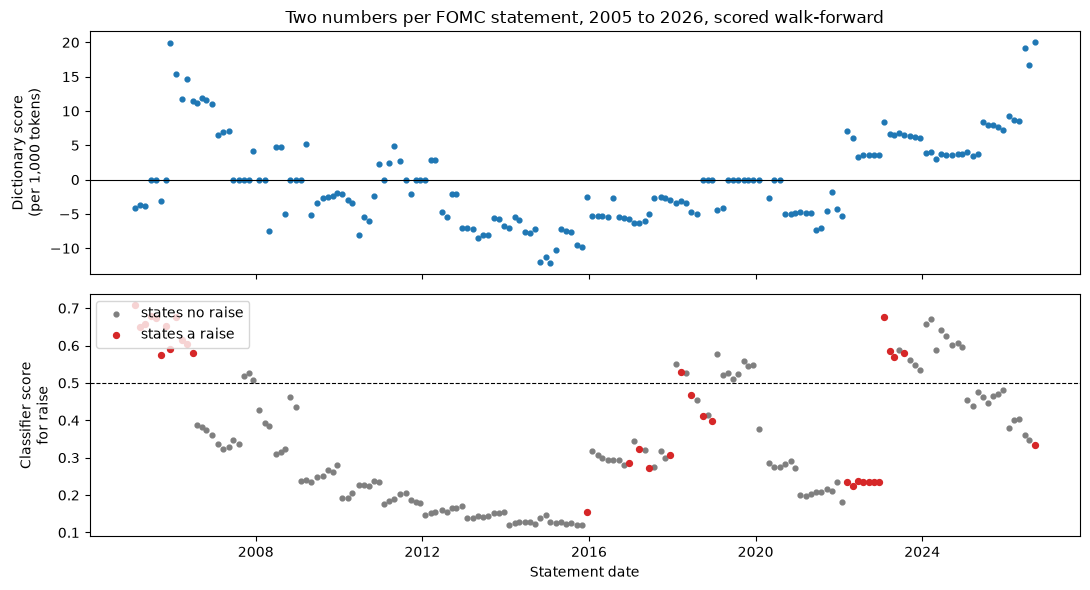

In [38]:
import matplotlib.pyplot as plt

fig, (top, bottom) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
dates = pd.to_datetime(both["date"])
stated = both["label"] == "raise"
top.scatter(dates, both["dictionary_score"], s=12, color="tab:blue")
top.axhline(0, color="black", linewidth=0.8)
top.set_ylabel("Dictionary score\n(per 1,000 tokens)")
top.set_title("Two numbers per FOMC statement, 2005 to 2026, scored walk-forward")
bottom.scatter(dates[~stated], both.loc[~stated, "score"], s=12, color="tab:gray", label="states no raise")
bottom.scatter(dates[stated], both.loc[stated, "score"], s=18, color="tab:red", label="states a raise")
bottom.axhline(0.5, color="black", linewidth=0.8, linestyle="--")
bottom.set_ylabel("Classifier score\nfor raise")
bottom.set_xlabel("Statement date")
bottom.legend(loc="upper left")
plt.tight_layout()
plt.show()

* The classifier's scores move in blocks: the statements of one year sit close together, above or below the dashed line at 0.5 as a group. Most red points of 2015 to 2018 and all of 2022 sit below it; the gray points of 2019 and 2024 sit above. The dictionary score moves in periods too, highest where "elevated" is frequent and lowest where "accommodative" is.

Q. How many statements does the classifier assign "raise", year by year, against the number that state one?

In [39]:
# year by year: how many statements state a raise, and how many the classifier assigns "raise"
per_year = results.groupby("year").agg(statements=("label", "size"), raise_stated=("label", lambda s: (s == "raise").sum()),
                                       assigned_raise=("assigned", lambda s: (s == "raise").sum()))
print(per_year.T.to_string())

year            2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  2025  2026
statements         8     8     8     8     8     8     8     8     8     8     8     8     8     8     8     7     8     8     8     8     8     6
raise_stated       8     4     0     0     0     0     0     0     0     0     1     1     3     4     0     0     0     7     4     0     0     1
assigned_raise     8     4     3     0     0     0     0     0     0     0     0     0     0     3     8     0     0     0     8     8     0     0


* In 19 of the 22 scored years every statement of the year gets the same label. Statements of one year share much of their wording, so a year comes out as a block: all raise (2005, 2019, 2023 and 2024) or all other. The model separates the wording of a period from the wording of the periods it was fitted on.

Q. Put a 95 percent interval on each walk-forward macro F1, from 1,000 resamples of the scored statements.

In [40]:
from sklearn.metrics import f1_score

# Course 5's module, written by the setup cell
import ensemblekit

# a 95 percent interval on each walk-forward macro F1: 1,000 resamples of the scored statements, Course 5's function
truth = (results["label"] == "raise").astype(int).to_numpy()


def macro_f1_of_flags(y_true, flags):
    return f1_score(y_true, np.asarray(flags).astype(int), average="macro")


intervals = {}
for name, frame in [("tfidf_logistic_balanced_action_left_in", leaky), ("tfidf_logistic_balanced", results)]:
    flags = (frame["assigned"] == "raise").astype(int).to_numpy()
    intervals[name] = ensemblekit.bootstrap_interval(truth, flags, macro_f1_of_flags, seed=SEED)
interval_table = pd.DataFrame(intervals, index=["lower", "upper"]).T
interval_table.insert(0, "macro_f1", summary.loc[interval_table.index, "macro_f1"])
print(interval_table.round(4).to_string())
print(f"majority label macro F1: {summary.loc['majority_label', 'macro_f1']:.4f}")

                                        macro_f1   lower   upper
tfidf_logistic_balanced_action_left_in    0.6562  0.5653  0.7341
tfidf_logistic_balanced                   0.6510  0.5615  0.7297
majority label macro F1: 0.4473


* The classifier on the kept text: 0.6510, interval 0.5615 to 0.7297. The lower end is above the majority label's 0.4473, so on these statements the classifier separates raise from other by more than the noise from which statements were scored.
* The run on the text as published: 0.5653 to 0.7341, almost the same interval: the two runs cannot be told apart here. The interval describes which statements were scored, not refitting; and because the statements of one year are alike, it is narrower than the year blocks justify.

## 5.7 The Results Workbook

Two sheets: `statements` (one row per scored statement: the action, the label, the counts, both numbers, the label assigned) and `summary` (the three rows of the walk-forward).

Q. Write `fomc_tone_day05.xlsx` and read it back.

In [41]:
# two sheets: one row per scored statement, and the walk-forward summary
statements_sheet = both.merge(scheduled[["date", "action", "firming", "easing", "tokens"]], on="date")[
    ["date", "action", "label", "firming", "easing", "tokens", "dictionary_score", "score", "assigned"]]
summary_sheet = summary.rename_axis("model").reset_index()
with pd.ExcelWriter("fomc_tone_day05.xlsx", engine="openpyxl") as writer:
    statements_sheet.to_excel(writer, sheet_name="statements", index=False)
    summary_sheet.to_excel(writer, sheet_name="summary", index=False)

# read every sheet back and check nothing changed on the way
back = pd.read_excel("fomc_tone_day05.xlsx", sheet_name=None)
print(f"sheets: {list(back)}; rows {[len(frame) for frame in back.values()]}")
for name, frame in [("statements", statements_sheet), ("summary", summary_sheet)]:
    pd.testing.assert_frame_equal(back[name], frame, check_exact=False, rtol=1e-12)
print("both sheets equal after the round trip")

sheets: ['statements', 'summary']; rows [173, 3]
both sheets equal after the round trip


* Two sheets, every cell back within 1e-12. Excel opened this workbook too (Excel Side by Side).

## 5.8 What the Model Shows, and Where It Fails

Q. Where is the classifier wrong? Count the raises it misses and the statements it assigns "raise" that state none, by year.

In [42]:
# where the classifier is wrong: misses and false flags, and years assigned all one way
missed = results[(results["label"] == "raise") & (results["assigned"] != "raise")]
false_flags = results[(results["label"] != "raise") & (results["assigned"] == "raise")]
print(f"raises missed: {len(missed)} of {(results['label'] == 'raise').sum()}, by year {missed['year'].value_counts().sort_index().to_dict()}")
print(f"false flags: {len(false_flags)}, by year {false_flags['year'].value_counts().sort_index().to_dict()}")
one_way = per_year[(per_year["assigned_raise"] == 0) | (per_year["assigned_raise"] == per_year["statements"])]
print(f"years in which every statement gets the same label: {len(one_way)} of {len(per_year)}")
print(f"years assigned raise throughout: {per_year.index[per_year['assigned_raise'] == per_year['statements']].tolist()}")

raises missed: 16 of 33, by year {2015: 1, 2016: 1, 2017: 3, 2018: 3, 2022: 7, 2026: 1}
false flags: 25, by year {2007: 3, 2018: 2, 2019: 8, 2023: 4, 2024: 8}
years in which every statement gets the same label: 19 of 22
years assigned raise throughout: [2005, 2019, 2023, 2024]


* It misses 16 of 33 raises, 7 of them in 2022, the first raises after three years (2019 to 2021) in which no scheduled statement stated one. It assigns "raise" to 25 statements that state none, 8 in 2019 and 8 in 2024: years that follow years of raises.

Q. Write the description, and check its words.

In [43]:
row = summary.loc["tfidf_logistic_balanced"]
low, high = interval_table.loc["tfidf_logistic_balanced", ["lower", "upper"]]
description = (
    f"On the {len(scheduled)} scheduled FOMC statements of 2000 to 2026, with every sentence naming the federal funds "
    f"rate or a target range removed, a TF-IDF logistic regression with balanced class weights was fitted year by "
    f"year on earlier years only and scored the {len(results)} statements of 2005 to 2026. Its walk-forward macro F1 "
    f"for raise against other was {row['macro_f1']:.4f} (bootstrap interval {low:.4f} to {high:.4f}), against "
    f"{summary.loc['majority_label', 'macro_f1']:.4f} for the majority label; it assigned raise to "
    f"{(results['assigned'] == 'raise').sum()} statements, of which {((results['assigned'] == 'raise') & (results['label'] == 'raise')).sum()} "
    f"state a raise, and it missed {len(missed)} of the {(results['label'] == 'raise').sum()} raises. In "
    f"{len(one_way)} of the {len(per_year)} scored years it gave every statement of the year the same label. "
    f"The dictionary score counts words from the course's two lists per thousand tokens; it sat on the same side "
    f"of its median as the classifier's score for {(high_score == high_dictionary).mean():.2%} of the statements. "
    f"Both numbers describe the wording of statements already published."
)
# stops on a forecast, advice, or lending word; a reminder, not a proof
mlkit.assert_descriptive(description)
print(description)

On the 213 scheduled FOMC statements of 2000 to 2026, with every sentence naming the federal funds rate or a target range removed, a TF-IDF logistic regression with balanced class weights was fitted year by year on earlier years only and scored the 173 statements of 2005 to 2026. Its walk-forward macro F1 for raise against other was 0.6510 (bootstrap interval 0.5615 to 0.7297), against 0.4473 for the majority label; it assigned raise to 42 statements, of which 17 state a raise, and it missed 16 of the 33 raises. In 19 of the 22 scored years it gave every statement of the year the same label. The dictionary score counts words from the course's two lists per thousand tokens; it sat on the same side of its median as the classifier's score for 68.21% of the statements. Both numbers describe the wording of statements already published.


The description passes the check, and it was read sentence by sentence as well, because the check is a reminder, not a proof.

**What the model shows.** On the 213 scheduled statements, with every sentence about the federal funds rate or a target range removed, a TF-IDF classifier fitted only on earlier years separates raise from other with a walk-forward macro F1 of 0.6510, above the majority label's 0.4473 by more than the resampling noise. What it finds are words that appear beside a stated change in the same statement, and above all the words of a period: it labels 19 of 22 years as a block. The dictionary score counts ten words per thousand tokens, mostly "elevated" and "accommodative", and sits on the same side of its median as the classifier's score for 68.2 percent of the statements.

**Where it fails.**

* **On the label.** `policy_action` gave 6 statements of 2015 the label raise from a sentence about a later raise; a second reading of the same text, the stated rate, caught it. A label read from text by a pattern is a claim to test.
* **On the leak.** Dropping the sentences about the rate removed the label's own words but not the related action on the discount rate, which stands beside a change in the target. The classifier leans on it.
* **On the years.** The classifier labels most years as a block, so it misses the first raises after a pause (2015 to 2018 and 2022) and assigns raise to whole years that state none (2019 and 2024).
* **On the words.** The dictionary score counts "not lower" as easing, counts no inflected form ("raised", "increases"), and depends on ten words chosen by the course.
* **On the interval.** Statements of one year are alike, so the resampling interval is narrower than the year blocks justify.

**What the data cannot support.** Both numbers describe the wording of statements already published. Neither says what the Committee intended, what it did at the next meeting, or what rates did afterwards; no score is lined up against later market moves, and none is a reading of policy.

**What was not tested.** Other word lists, other weights, and other models; the unscheduled releases; the discount rate sentence removed as well; and any statement after 2026-09-16, which the file does not hold.

## Excel Side by Side

Excel has no tokenizer, no TF-IDF, and no classifier on text, so the walk-forward of section 5.5 has no Excel counterpart. The dictionary count does. Every formula below was typed into Excel by script (Excel 16.0 build 20430, 2026-10-08) on today's own text: the kept text of each of the 213 scheduled statements in A2:A214, one per row, formatted as Text; the firming list in H1:H5 and the easing list in I1:I5, given the names `pos` and `neg` (a named range: a name that stands for a block of cells); and in column B each statement's token count from `textkit.tokenize`, pasted as numbers, because Excel has no tokenizer to count them.

| Job | Python | Excel | Excel returned (statement of 2008-09-16) |
| --- | --- | --- | --- |
| Firming words in a statement | `sum(text.lower().count(w) for w in FIRMING)` | `=SUMPRODUCT((LEN(LOWER(A2))-LEN(SUBSTITUTE(LOWER(A2),pos,"")))/LEN(pos))` | 2 |
| Easing words in a statement | the same with `EASING` | `=SUMPRODUCT((LEN(LOWER(A2))-LEN(SUBSTITUTE(LOWER(A2),neg,"")))/LEN(neg))` | 1 |
| The score per thousand tokens | `(firming - easing) / tokens * 1000` | `=(C2-D2)/B2*1000` | 4.9505 |
| The same count, whole words | `textkit.dictionary_score(textkit.tokenize(text), ...)` | no worksheet function | firming 0, easing 1, score -4.9505 |

**How the formula counts.** `LOWER(A2)` makes the statement lower case. `SUBSTITUTE(LOWER(A2),pos,"")` is given the whole list `pos`, so Excel works it out once per word: the statement with every "raise" removed, then with every "increase" removed, and so on. `LEN` of the statement minus `LEN` of each of those, divided by `LEN(pos)` (each word's length), is how many times each word occurs, and `SUMPRODUCT` adds the five counts. It is day 1's `LEN` and `SUBSTITUTE` count, run over a list.

**The substring difference, measured.** On all 213 rows Excel's two counts equal Python's substring counts (`str.count` on the lower-case text), and the scores agree within 1e-12. They are not `dictionary_score`'s counts: Excel counts a word wherever its letters occur, and `tokenize` counts whole words. The counts differ on 97 of the 213 statements (firming on 65, easing on 38): Excel counts 268 firming and 356 easing words in all, against 194 and 315 whole words. The longer words that hold a listed word, counted in Python on the same tokens: "increased" 33, "increases" 30, "increasing" 14, "slower" 11, "tightening" 10, "still-increasing" 7. So "increased" and "increases" count as "increase", "slower" counts as "lower", and "increasing" counts as **"easing"**, whose letters it holds.

**One statement, two signs.** The statement of 2008-09-16 (202 tokens) is where the two differ most. Its kept text holds "increased", "increases". Excel's count gives firming 2 and easing 1, a score of 4.9505; the whole-word count gives 0 and 1, a score of -4.9505. Same statement, same lists, opposite signs. Neither is wrong as arithmetic: they count different things, and a score is only as clear as its definition of a word. To match `tokenize` in Excel you would have to split each statement into words first.

**The workbook.** The check wrote `fomc_tone_day05.xlsx` with the notebook's own code from the same two tables, and Excel opened it read-only: the sheets `statements` and `summary`, in that order, with 173 and 3 rows below their headers, and every cell equal to the notebook's tables (dates and labels as text, numbers within 1e-12).

Q. Do Excel's numbers equal Python's substring counts on the same statement, and how far are they from the whole-word counts?

In [44]:
# Excel's results, from the course's Excel check, beside Python's substring count and textkit's whole-word count
one = scheduled.loc[scheduled["date"] == "2008-09-16"].iloc[0]
text = one["kept"].lower()
substring_firming = sum(text.count(w) for w in FIRMING)
substring_easing = sum(text.count(w) for w in EASING)
excel = {"firming": 2, "easing": 1, "score": 4.9504950495049505,
         "firming, all statements": 268, "easing, all statements": 356}
python = {"firming": substring_firming, "easing": substring_easing,
          "score": (substring_firming - substring_easing) / one["tokens"] * 1000,
          "firming, all statements": sum(k.lower().count(w) for k in scheduled["kept"] for w in FIRMING),
          "easing, all statements": sum(k.lower().count(w) for k in scheduled["kept"] for w in EASING)}
whole = {"firming": one["firming"], "easing": one["easing"], "score": one["dictionary_score"],
         "firming, all statements": scheduled["firming"].sum(), "easing, all statements": scheduled["easing"].sum()}
side_by_side = pd.DataFrame({"Excel": excel, "Python substrings": python})
side_by_side["equal"] = [abs(a - b) < 1e-12 for a, b in zip(side_by_side["Excel"], side_by_side["Python substrings"])]
side_by_side["textkit whole words"] = pd.Series(whole)
print(side_by_side.round(4).to_string())

                            Excel  Python substrings  equal  textkit whole words
firming                    2.0000             2.0000   True               0.0000
easing                     1.0000             1.0000   True               1.0000
score                      4.9505             4.9505   True              -4.9505
firming, all statements  268.0000           268.0000   True             194.0000
easing, all statements   356.0000           356.0000   True             315.0000


* Excel equals Python's substring count on every row, and neither equals the whole-word count. The trap of day 1 at the scale of a list: decide what a word is before you count it, in either tool.

## Save the Day with Git

The work folder gets its own repository. The first commit holds the earlier modules today's setup wrote and the two `textkit` files as they stand after today's three functions; the second, the walk-forward results; then the end of week 1 gets a tag.

Q. Make the work folder a repository.

In [45]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [46]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course7_05_2m0xwads and nowhere else


Q. Write the same `.gitignore` as day 1, and commit the modules.

In [47]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx
.env
cache/

Writing .gitignore


In [48]:
!git -C "{work}" add .gitignore mlkit.py ensemblekit.py textkit.py test_textkit.py
!git -C "{work}" commit -q -m "Add dictionary_score, policy_action, drop_sentences, 30 tests"
!git -C "{work}" show --stat --format=%s HEAD

Add dictionary_score, policy_action, drop_sentences, 30 tests

 .gitignore      |   5 +
 ensemblekit.py  | 624 ++++++++++++++++++++++++++++++++++++++++++++++++++++++++
 mlkit.py        | 568 +++++++++++++++++++++++++++++++++++++++++++++++++++
 test_textkit.py | 288 ++++++++++++++++++++++++++
 textkit.py      | 468 ++++++++++++++++++++++++++++++++++++++++++
 5 files changed, 1953 insertions(+)


* The workbook is not committed: `*.xlsx` is ignored, as in every course. `results.csv` is the log Git keeps.

Q. Write the walk-forward results to `results.csv`, four decimals, and commit it.

In [49]:
# the experiment log: one row per model, the course's columns for a two-label walk-forward
log = summary.rename_axis("model").reset_index()[["model", "rows", "macro_f1", "accuracy", "recall_raise", "n"]]
log.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print(Path("results.csv").read_text(encoding="utf-8"))

model,rows,macro_f1,accuracy,recall_raise,n
majority_label,walk-forward,0.4473,0.8092,0.0000,173
tfidf_logistic_balanced_action_left_in,walk-forward,0.6562,0.7688,0.5152,173
tfidf_logistic_balanced,walk-forward,0.6510,0.7630,0.5152,173



In [50]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Log the walk-forward results of day 5"
!git -C "{work}" log --oneline

4a2daf7 Log the walk-forward results of day 5


ac281ac Add dictionary_score, policy_action, drop_sentences, 30 tests


* `recall_raise` takes the place of the 8-K days' two rare-item recalls: here the rare label is raise.

Q. Week 1 ends here. Tag the commit, and show what the last commit of the week changed.

In [51]:
# a tag is a name for one commit; week1~1 is the commit before it
!git -C "{work}" tag week1
!git -C "{work}" tag --list
!git -C "{work}" diff --stat week1~1 week1

week1


 results.csv | 4 ++++
 1 file changed, 4 insertions(+)


* A **tag** names a commit for good: `week1` will always mean this commit, whatever comes after. `week1~1` is the commit one before it, so the diff shows exactly what the last commit of the week added: `results.csv`.

## Bring It Home

Add today's three functions to your own `textkit.py` in `my_bondmath`. Open a PowerShell terminal in VS Code.

**Step 1.** Go to your folder and open the two files.

```powershell
Set-Location "$HOME\projects\my_bondmath"
code textkit.py
code test_textkit.py
```

**Step 2.** Paste the code of today's three `%%writefile -a textkit.py` cells (sections 5.1, 5.2, and 5.4), without their first lines, at the end of `textkit.py`, in that order; do the same for the three `test_textkit.py` cells. Save both.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_textkit.py
```

The last line says `30 passed`.

**Step 4.** Read the change, commit it, and tag the end of week 1.

```powershell
git diff --stat
git add textkit.py test_textkit.py
git commit -m "Add dictionary_score, policy_action, drop_sentences, 30 tests"
git tag week1
git log --oneline -3
```

**In Colab**, download `textkit.py` and `test_textkit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Write a word list, print it in full, say that it is a choice, and score a text with `dictionary_score` per thousand tokens.
* Read the action a statement states with `policy_action`, and test the reading against another thing the statement states.
* Find the label in the text, show what a model leans on when it is left in, and remove it with `drop_sentences` before any model sees the text.
* Score dated documents walk-forward by year, each year by a model fitted on earlier years only, and report macro F1 against the majority label with a bootstrap interval.
* Put two numbers side by side by date, and say what each counts and where each fails.
* Count list words in Excel with `SUMPRODUCT`, `LEN`, and `SUBSTITUTE` over a named range, and say how a substring count differs from a whole-word count.
* Tag a commit with `git tag`.

Next, day 6: sentence embeddings and semantic search, the first day of week 2, with a small model on your own CPU.

## Exercises

The exercises use the 213 scheduled statements and their kept text, described only: counts and scores for stated dates. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the statements, reads each one's action, drops the sentences about the rate (section 5.4), and defines `check`, a small function that marks your answers.

In [52]:
import re

from sklearn.metrics import f1_score

# the scheduled statements, the action each states, and the kept text (the case study's preparation)
fomc = pd.read_csv("course7_fomc_statements.csv")
fomc["year"] = fomc["date"].str[:4].astype(int)
scheduled = fomc[fomc["scheduled"]].reset_index(drop=True)
scheduled["action"] = [textkit.policy_action(t) for t in scheduled["text"]]
scheduled["kept"] = [textkit.drop_sentences(t, r"federal funds|target range")[0] for t in scheduled["text"]]
FIRMING = ['raise', 'increase', 'tighten', 'firming', 'elevated']
EASING = ['lower', 'reduce', 'accommodation', 'accommodative', 'easing']


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Take "elevated" off the firming list and score every statement again on its kept text. How many of the scheduled statements' scores change? Store the count in **ex1_changed** and the median of the new scores in **ex1_median** (a `float`).

In [53]:
ex1_changed = ...
ex1_median = ...

In [54]:
check("Exercise 1 statements whose score changes", ex1_changed, 90)
check("Exercise 1 the median score", ex1_median, -2.717391304347826)

Exercise 1 statements whose score changes: not attempted yet
Exercise 1 the median score: not attempted yet


### Exercise 2

Q. Run the walk-forward for "lower" against "other": label each scheduled statement "lower" where `policy_action` says lower (section 5.2 found it agrees with the stated rate on every statement), fit `textkit.text_classifier(class_weight="balanced")` on the kept text of the years before each year from 2005, and assign each year's statements. Store the walk-forward macro F1 in **ex2_macro_f1** (a `float`).

In [55]:
ex2_macro_f1 = ...

In [56]:
check("Exercise 2 walk-forward macro F1 for lower", ex2_macro_f1, 0.6048080060915915)

Exercise 2 walk-forward macro F1 for lower: not attempted yet


### Exercise 3

Q. Add a function to your module. `score_by_year(frame)` takes a frame with a `date` column (ISO text) and a `score` column, and returns one row per year, indexed by the year as an `int`, with the count, mean, and median of the score; it raises `ValueError` on an empty frame or a missing column. Write the docstring first. Then add `test_score_by_year_hand`, which checks a three-row frame by hand and that a frame without `score` raises. Run pytest, reload the module, run it on the dictionary scores of the scheduled statements, and store the year with the highest median score in **ex3_highest_year** (an `int`).

Write the function in the cell that starts with `%%writefile -a textkit.py` and the test in the one that starts with `%%writefile -a test_textkit.py`, and run each of those cells once.

In [57]:
%%writefile -a textkit.py


# Exercise 3: write score_by_year(frame) below this line

Appending to textkit.py


In [58]:
%%writefile -a test_textkit.py


# Exercise 3: write test_score_by_year_hand() below this line

Appending to test_textkit.py


In [59]:
# run pytest, reload the module, then run your function
ex3_highest_year = ...

In [60]:
check("Exercise 3 the year with the highest median score", ex3_highest_year, 2026)

Exercise 3 the year with the highest median score: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a dictionary score that leaves out the sentences holding "not", so that a negated word ("did not raise") is never counted, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Dictionary score of one statement, leaving out every sentence that holds the word "not".

    Inputs: text, one statement (its kept text); positive and negative, the course's two word lists.
    Output: textkit.dictionary_score's dict, computed on the tokens of the sentences that hold no "not". In
    "The Committee did not raise the target range." no word is counted, so a negated word never adds to a count.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns a plausible score, and contains one bug.

In [61]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
import re


def score_outside_negations(text, positive, negative):
    """Dictionary score of one statement, leaving out every sentence that holds the word "not".

    Inputs: text, one statement (its kept text); positive and negative, the course's two word lists.
    Output: textkit.dictionary_score's dict, computed on the tokens of the sentences that hold no "not". In
    "The Committee did not raise the target range." no word is counted, so a negated word never adds to a count.
    """
    kept_tokens = []
    for sentence in re.split(r"(?<=[.!?])\s+", textkit.normalize_text(text)):
        tokens = textkit.tokenize(sentence)
        # leave out a sentence with a negation
        if "Not" in tokens:
            continue
        kept_tokens += tokens
    return textkit.dictionary_score(kept_tokens, positive, negative)

Q. Before you run the next cell: of the 213 statements, for how many does the function's score differ from `dictionary_score` on all the tokens of the kept text? Some kept texts do hold "not".

In [62]:
# the function beside dictionary_score on all the kept tokens, for every scheduled statement
plain = [textkit.dictionary_score(textkit.tokenize(k), set(FIRMING), set(EASING))["score"] for k in scheduled["kept"]]
outside = [score_outside_negations(k, set(FIRMING), set(EASING))["score"] for k in scheduled["kept"]]
print(f"statements whose score differs from dictionary_score on all tokens: {sum(a != b for a, b in zip(plain, outside))} of {len(plain)}")
print(f'kept texts with a sentence that holds "not": {sum("not" in textkit.tokenize(k) for k in scheduled["kept"])}')

statements whose score differs from dictionary_score on all tokens: 0 of 213


kept texts with a sentence that holds "not": 26


Q. Test the function against its docstring before you trust it: in a text of two sentences, the second with "not", only the first may be counted.

In [63]:
# the test, written from the docstring before the code is trusted
hand = score_outside_negations("Inflation remains elevated. The Committee did not raise the target range.",
                               {"raise", "elevated"}, {"lower"})
assert hand["positive"] == 1, f"firming words counted: {hand['positive']}, the docstring says 1 (elevated only)"
assert hand["tokens"] == 3, f"tokens counted: {hand['tokens']}, the docstring says 3 (the first sentence only)"
print(f"the negated sentence is left out: {hand}")

AssertionError: firming words counted: 2, the docstring says 1 (elevated only)

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store how many of the scheduled statements' scores change once the negated sentences are left out in **ex4_changed**.

In [64]:
# fix the function above and run the test again, then store the answer
ex4_changed = ...

In [65]:
check("Exercise 4 statements whose score changes", ex4_changed, 25)

Exercise 4 statements whose score changes: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```